In [1]:
from pathlib import Path

from data_loading import sync_open_data_sessions

In [2]:
SUBJECT_IDS = ["841312", "841299", "866063", "864846", "864845"]
START_DATE = "2026-06-01"
OUTPUT_ROOT = Path("./data")
if False:
    sync_open_data_sessions(
        subject_ids=SUBJECT_IDS,
        start_date=START_DATE,
        output_root=OUTPUT_ROOT,
        confirm=False,
    )
    !uv run python process_sessions.py

In [3]:
import pandas as pd
import numpy as np
from helpers import assign_blocks, trim_sessions

trials = pd.read_parquet("data/processed/trials.parquet")
trials = assign_blocks(trials)
trials = trim_sessions(trials, start_frac=0.0, end_frac=0.7)


def is_rewarded(patch_label: str) -> bool:
    return "NonRewarded" not in patch_label


def odor_index(odor_concentration: list[float] | np.ndarray) -> int:
    return np.argmax(np.array(odor_concentration))


trials["is_rewarded_odor"] = trials["patch_label"].apply(is_rewarded)
trials["odor_index"] = trials["odor_concentration"].apply(odor_index)

Animal 841312
Animal 841299
Animal 866063
Animal 864846
Animal 864845


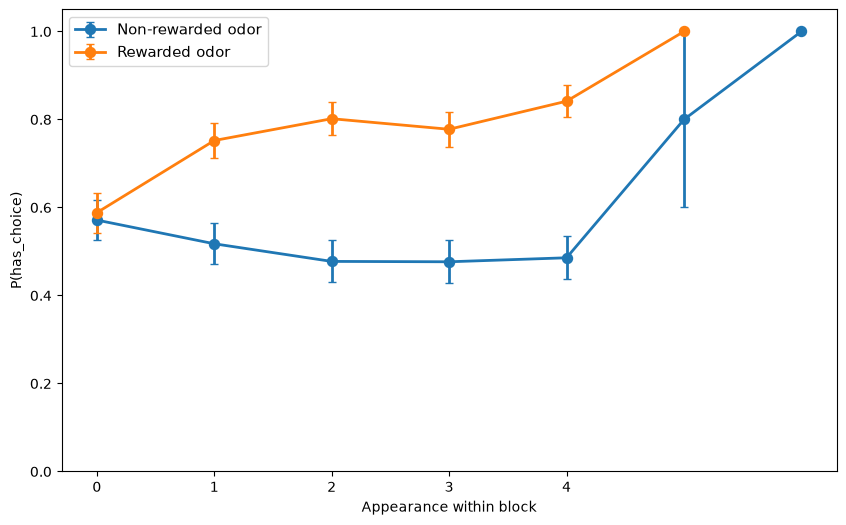

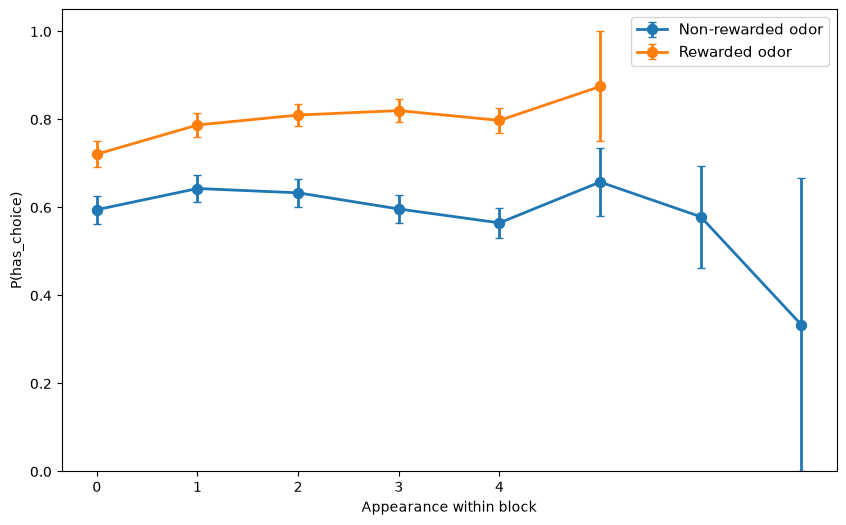

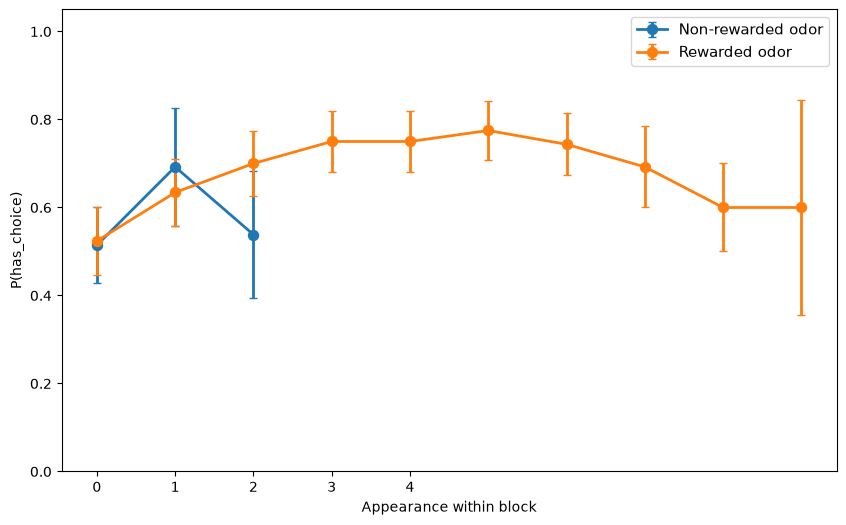

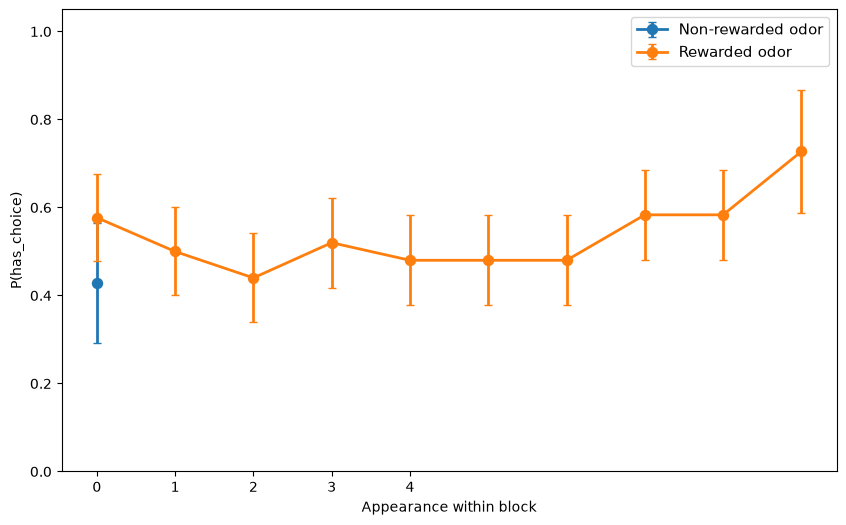

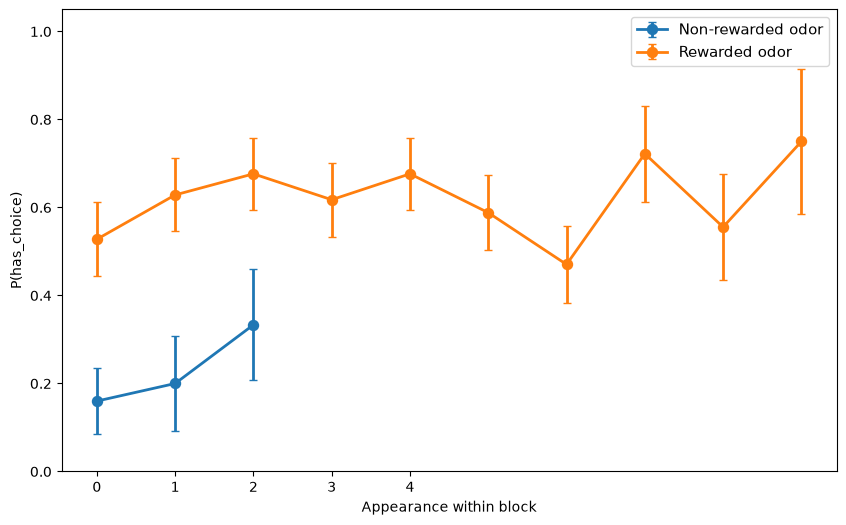

In [4]:
from helpers import plot_choice_by_block_position
from viz_helpers import a_lot_of_style
from matplotlib import pyplot as plt

for animal in SUBJECT_IDS:
    print(f"Animal {animal}")
    fig = plt.figure(figsize=(10, 6))
    ax = fig.add_subplot(111)
    with a_lot_of_style():
        plot_choice_by_block_position(
            trials[trials["session_id"].str.startswith(animal)], ax=ax
        )

plt.show()

c:\git\bruno-f-cruz\analysis-harlow-learning-sets\helpers.py:183: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()
c:\git\bruno-f-cruz\analysis-harlow-learning-sets\helpers.py:183: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


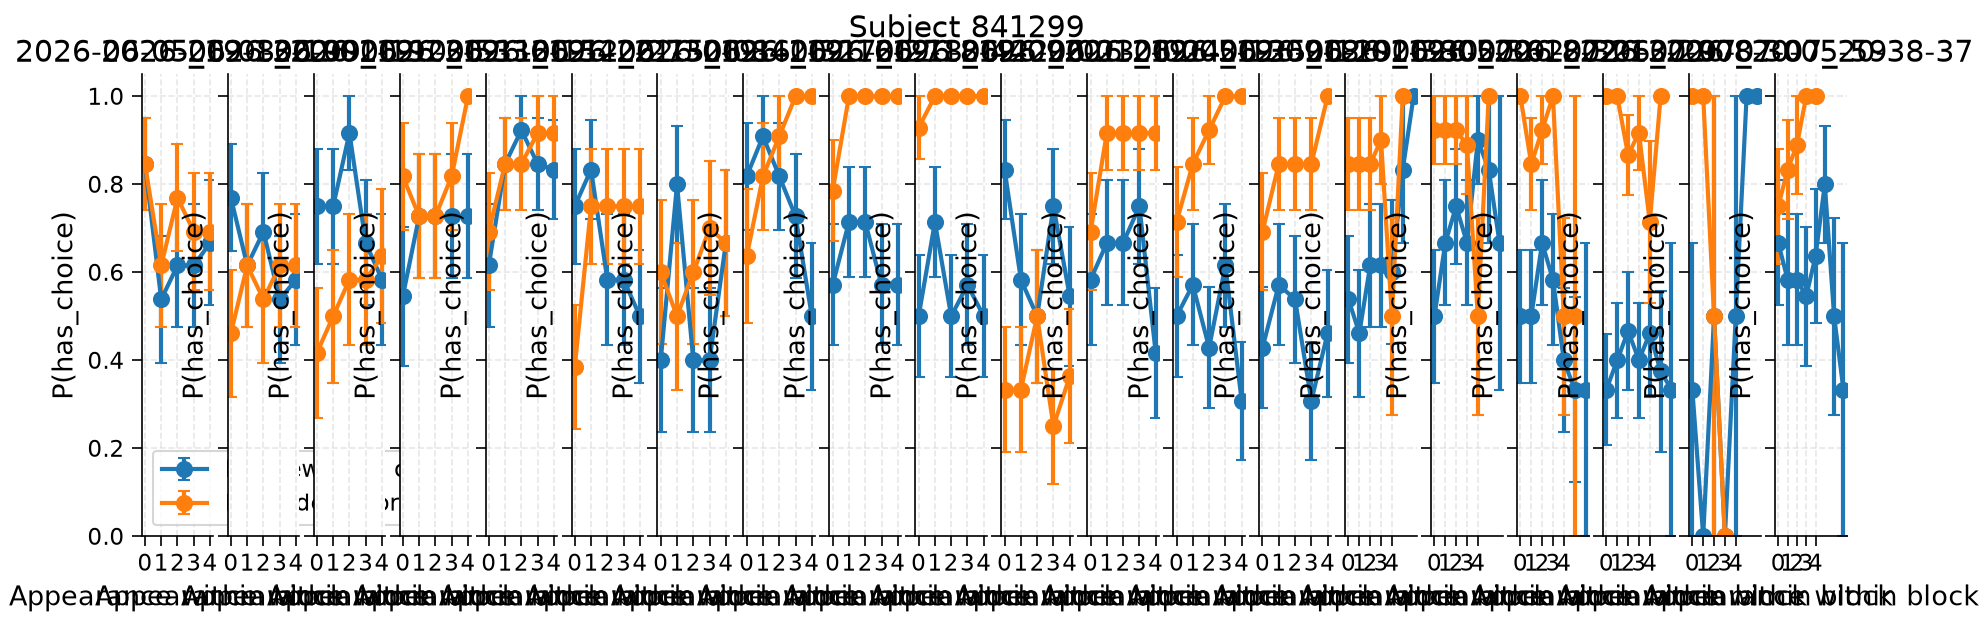

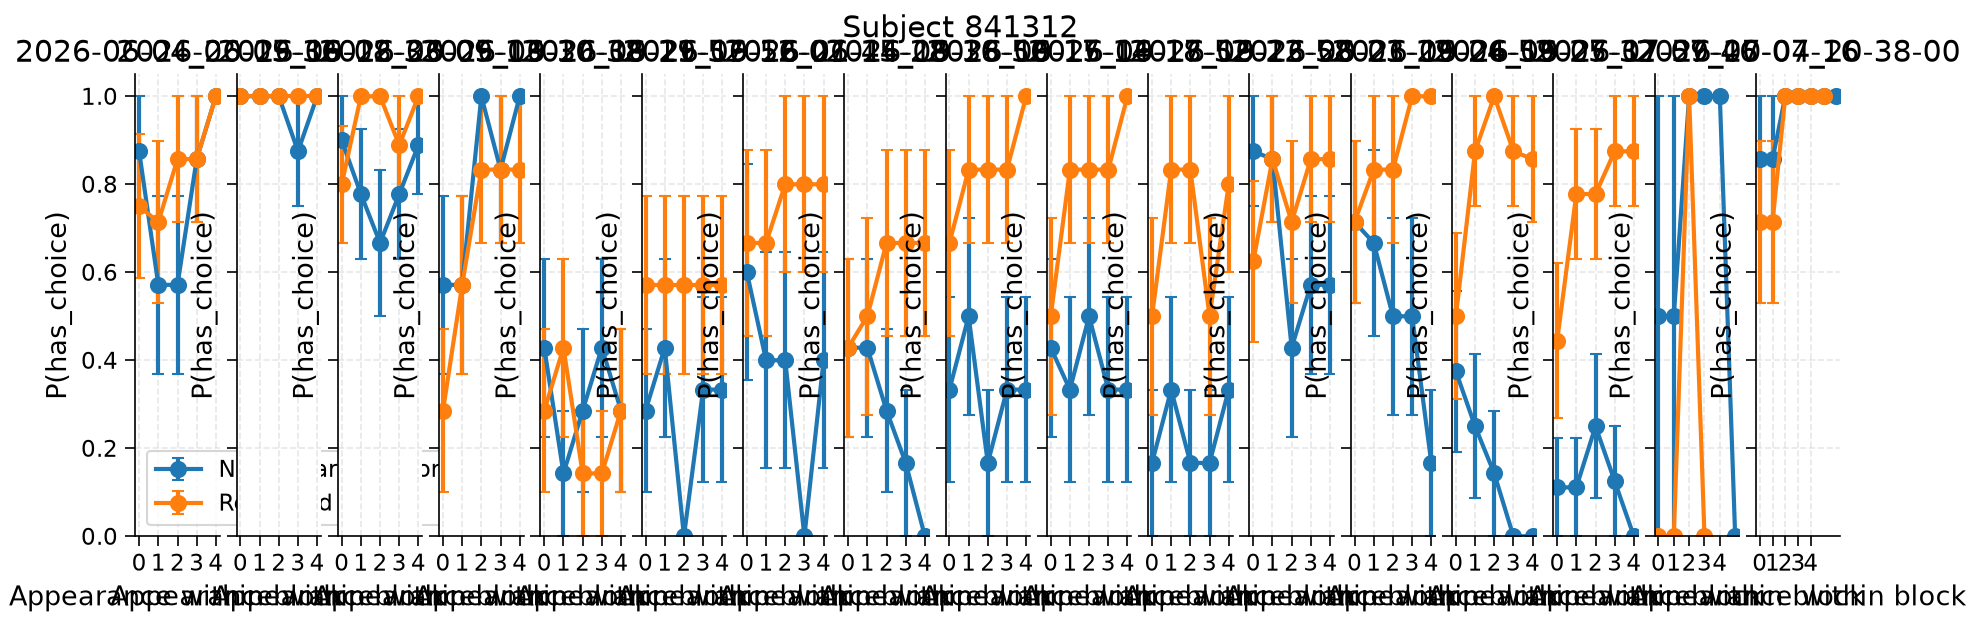

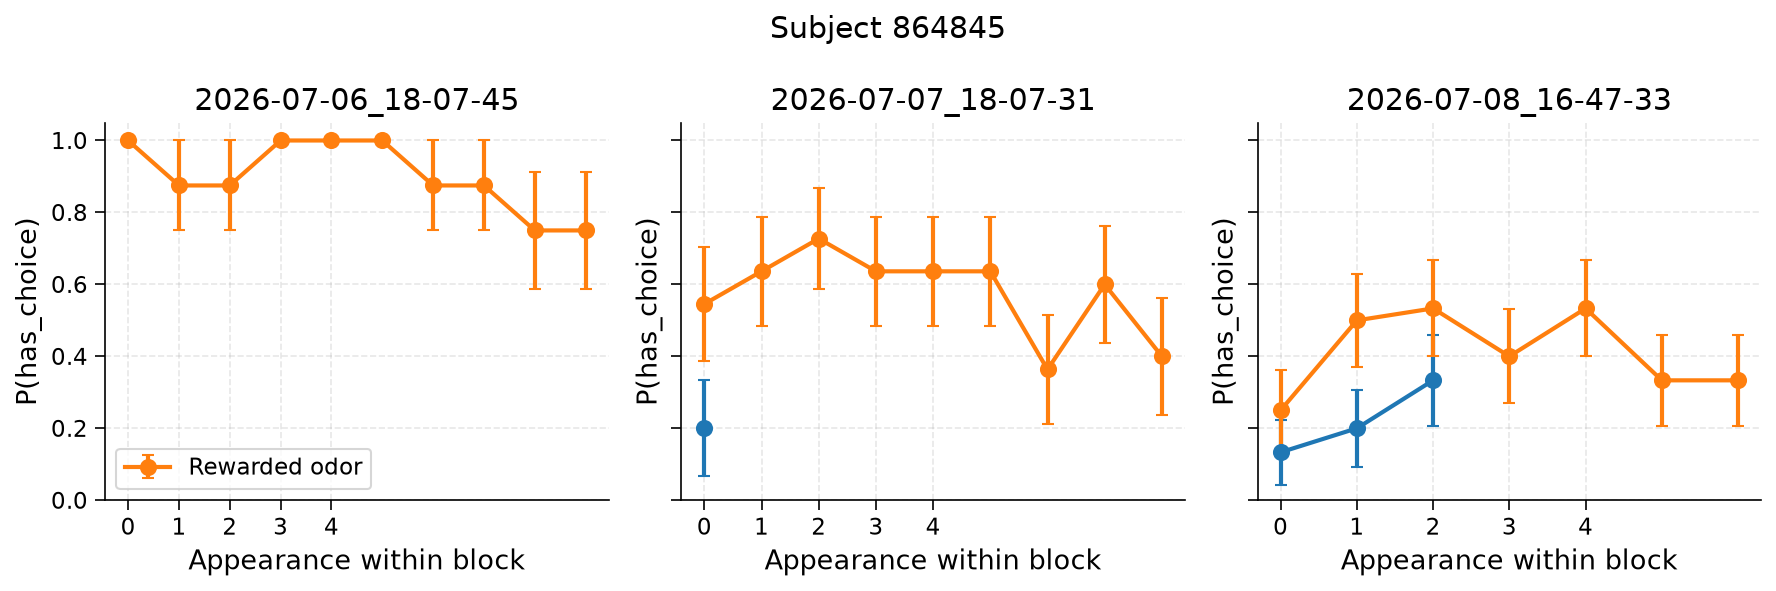

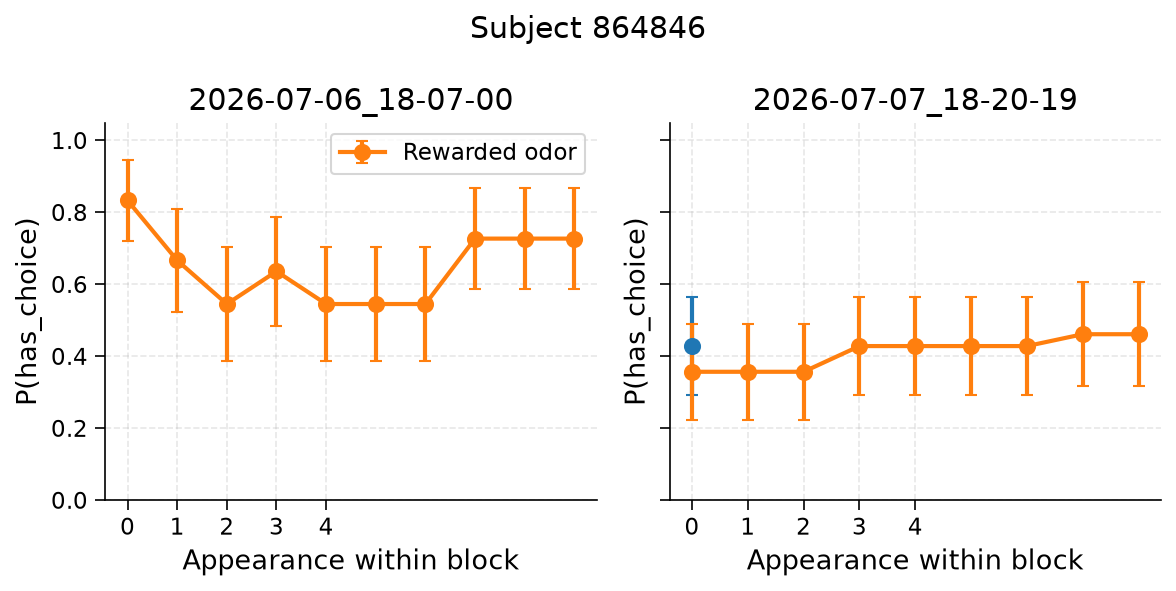

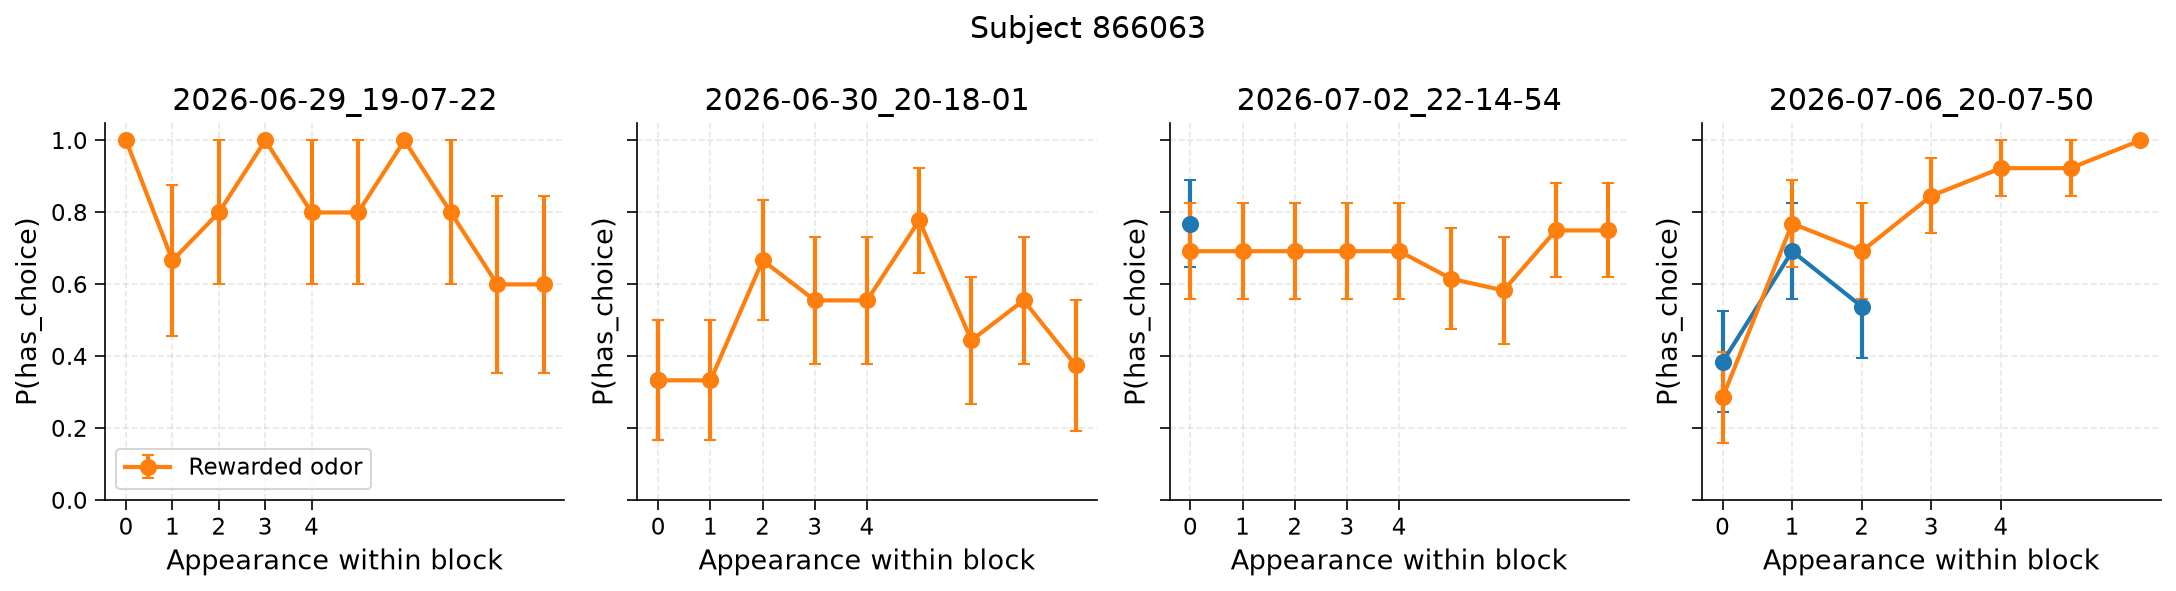

In [5]:
from helpers import plot_choice_by_block_position_per_session

with a_lot_of_style():
    plot_choice_by_block_position_per_session(trials)

plt.show()

c:\git\bruno-f-cruz\analysis-harlow-learning-sets\helpers.py:183: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()
c:\git\bruno-f-cruz\analysis-harlow-learning-sets\helpers.py:183: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()
c:\git\bruno-f-cruz\analysis-harlow-learning-sets\helpers.py:183: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


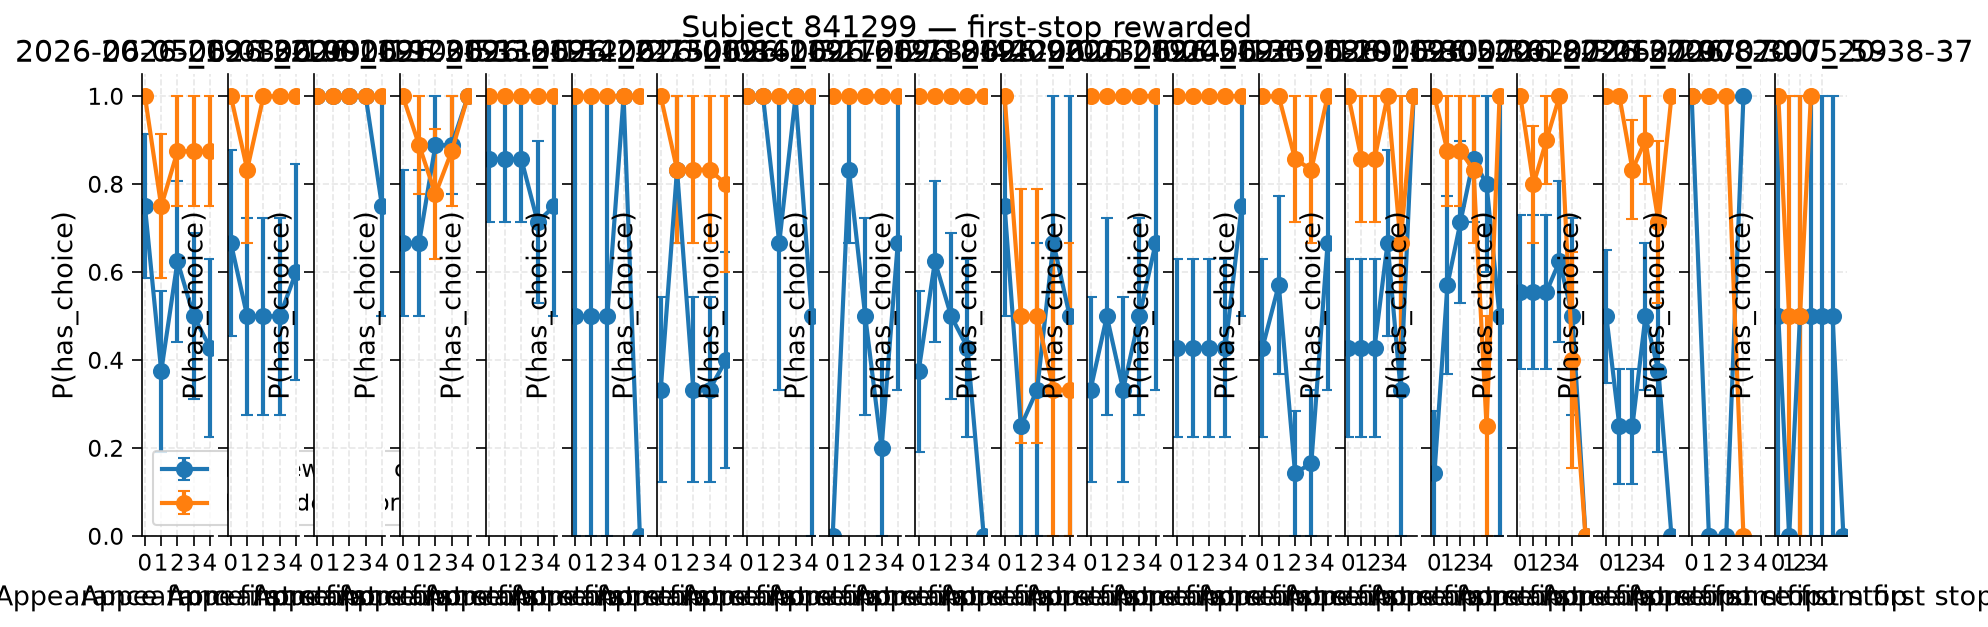

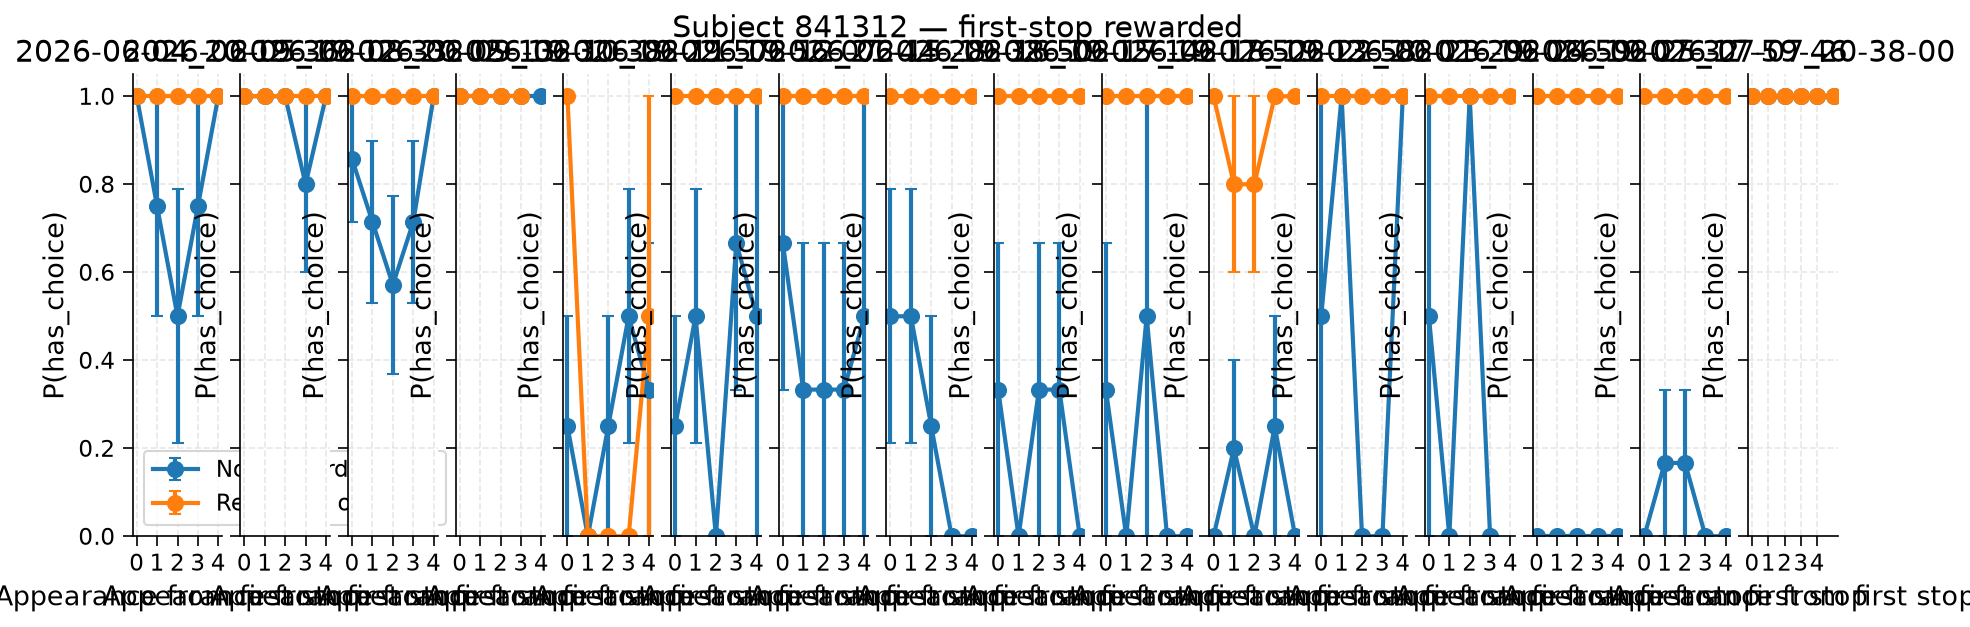

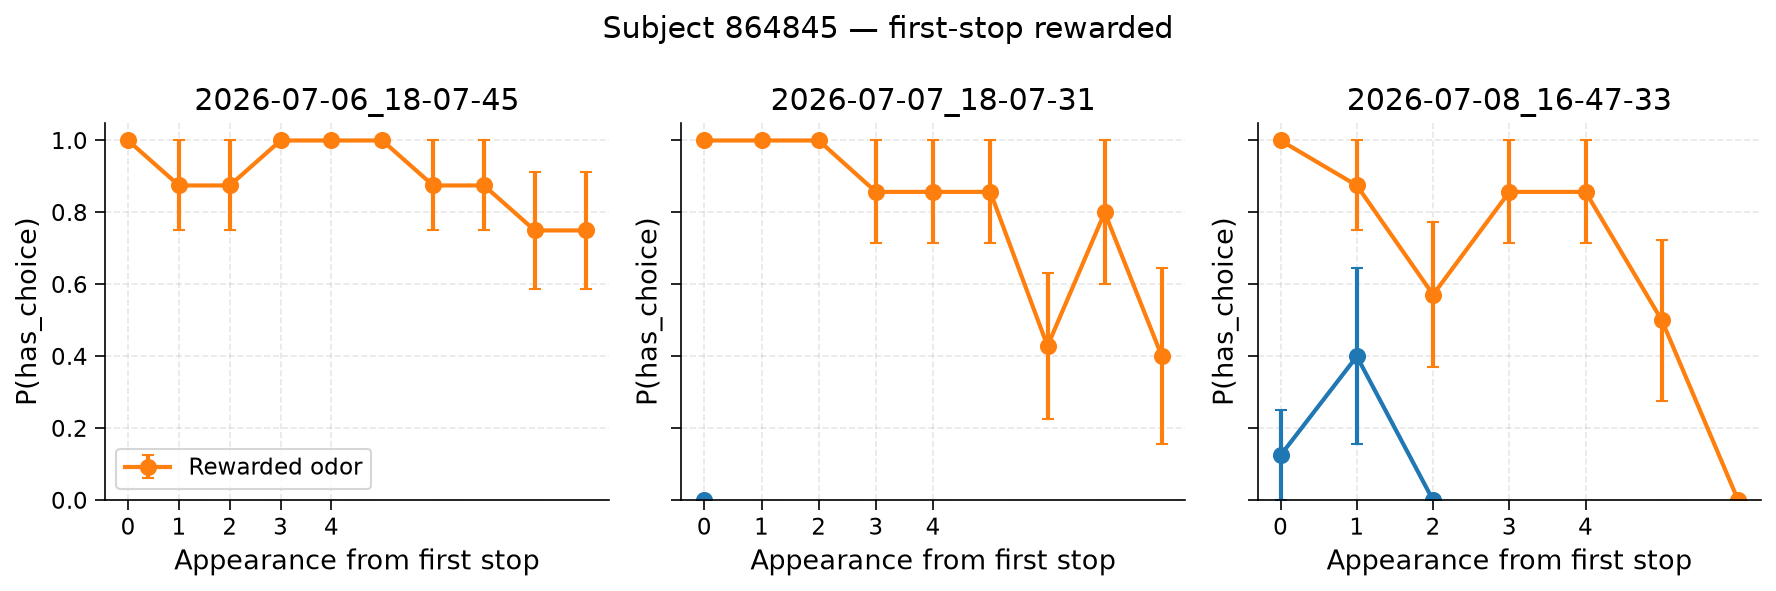

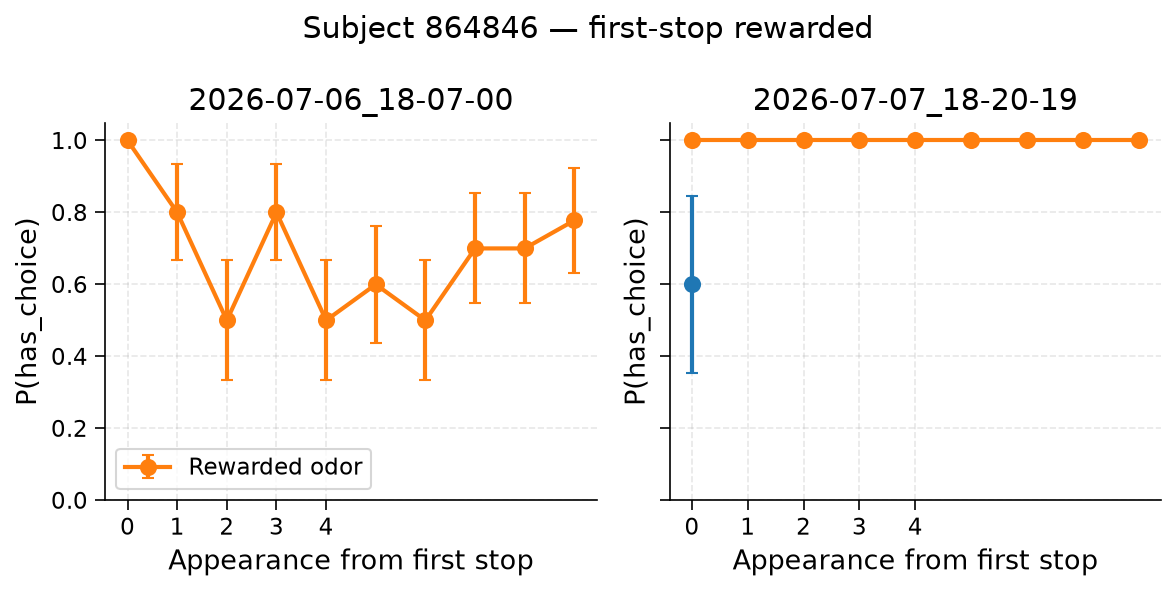

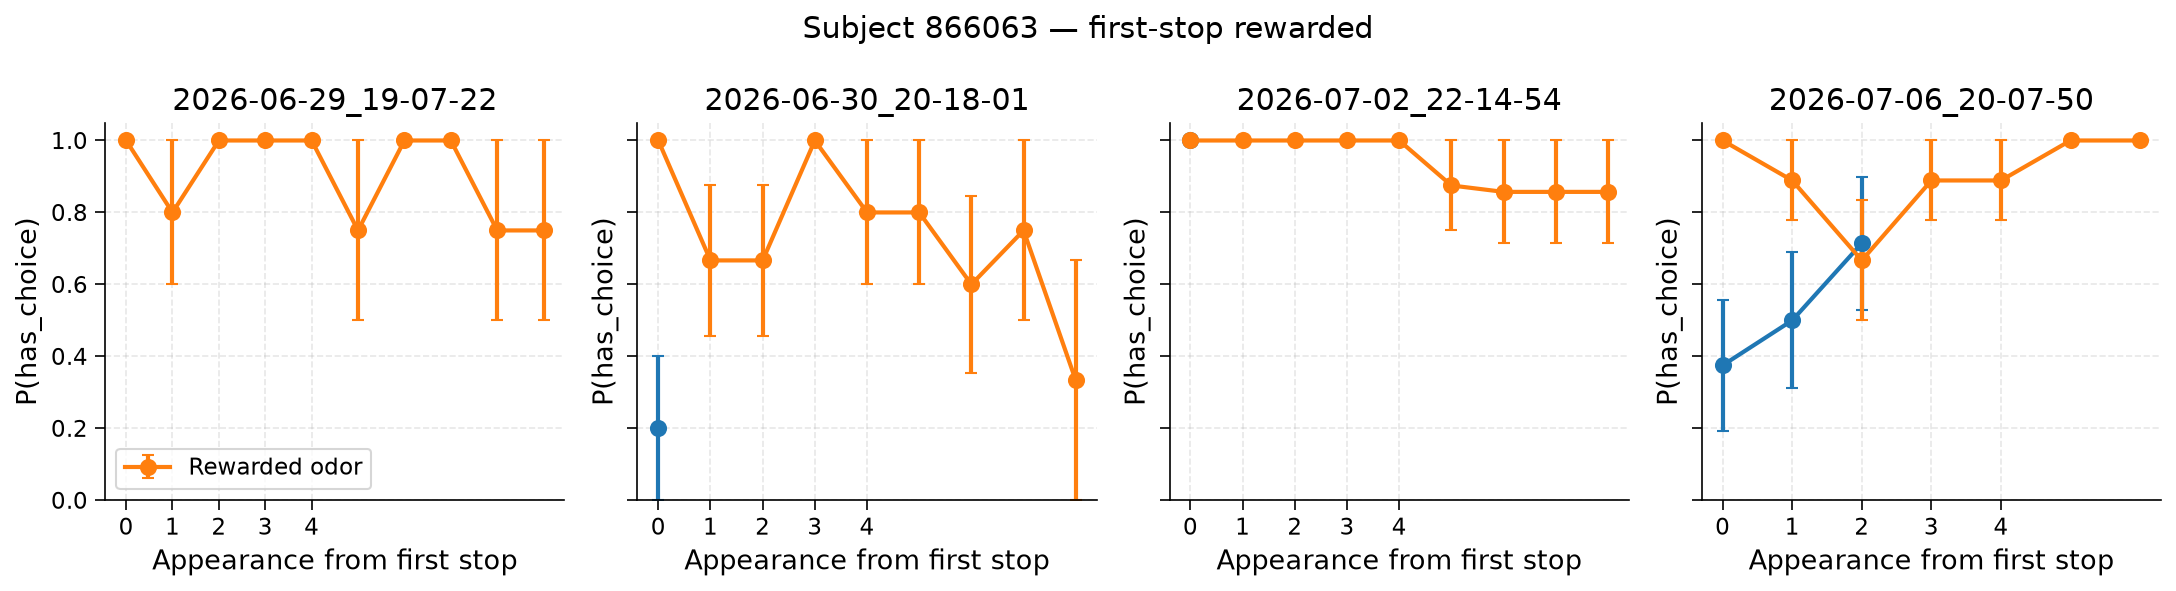

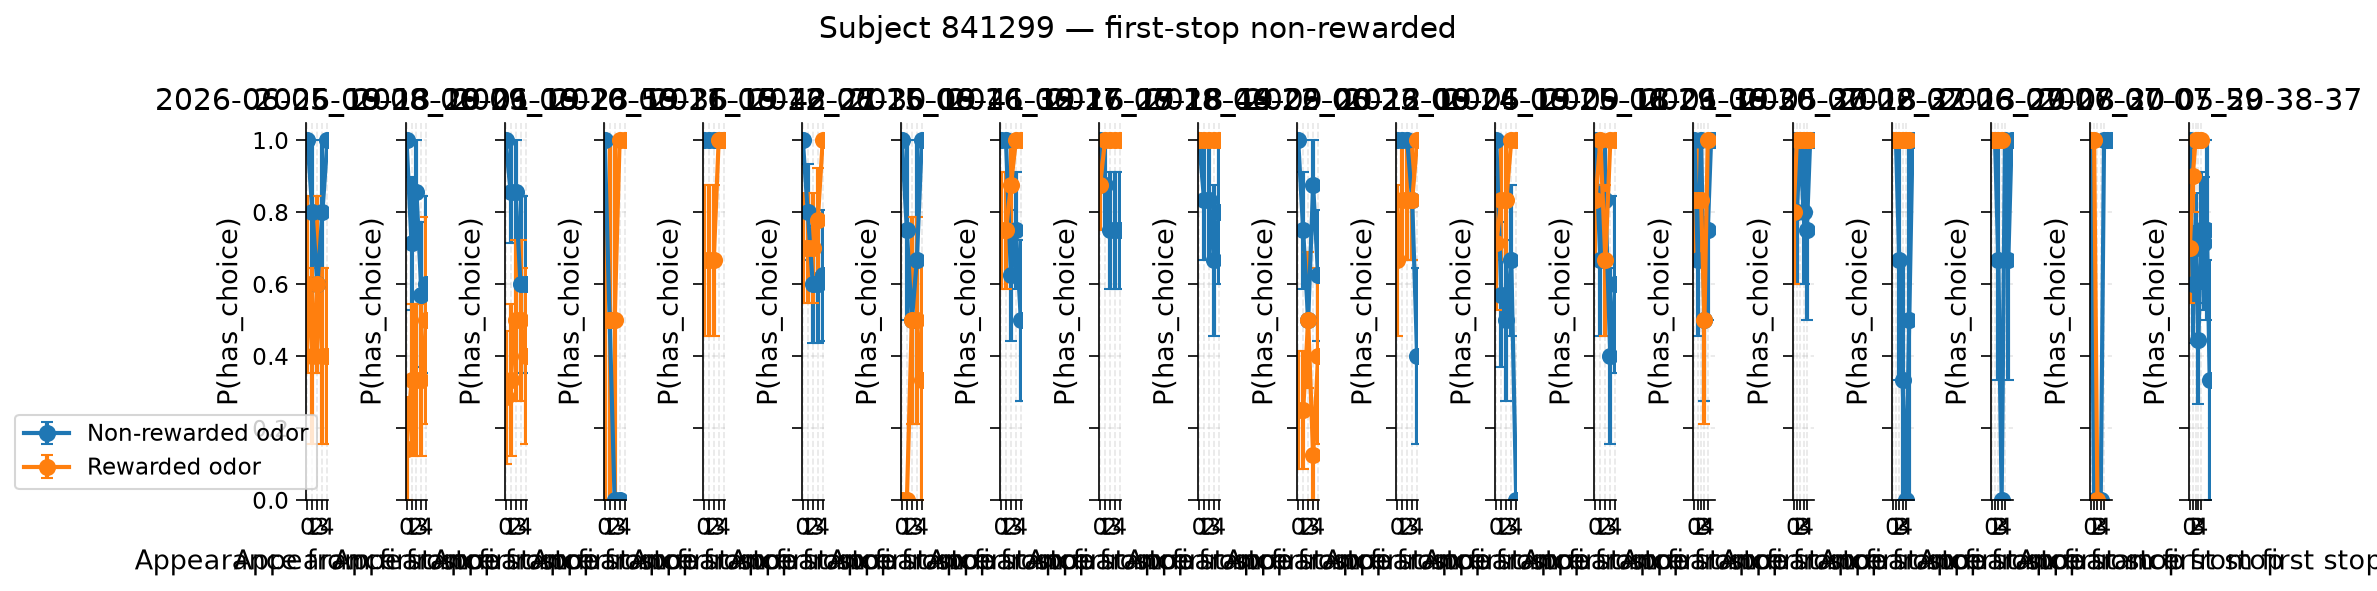

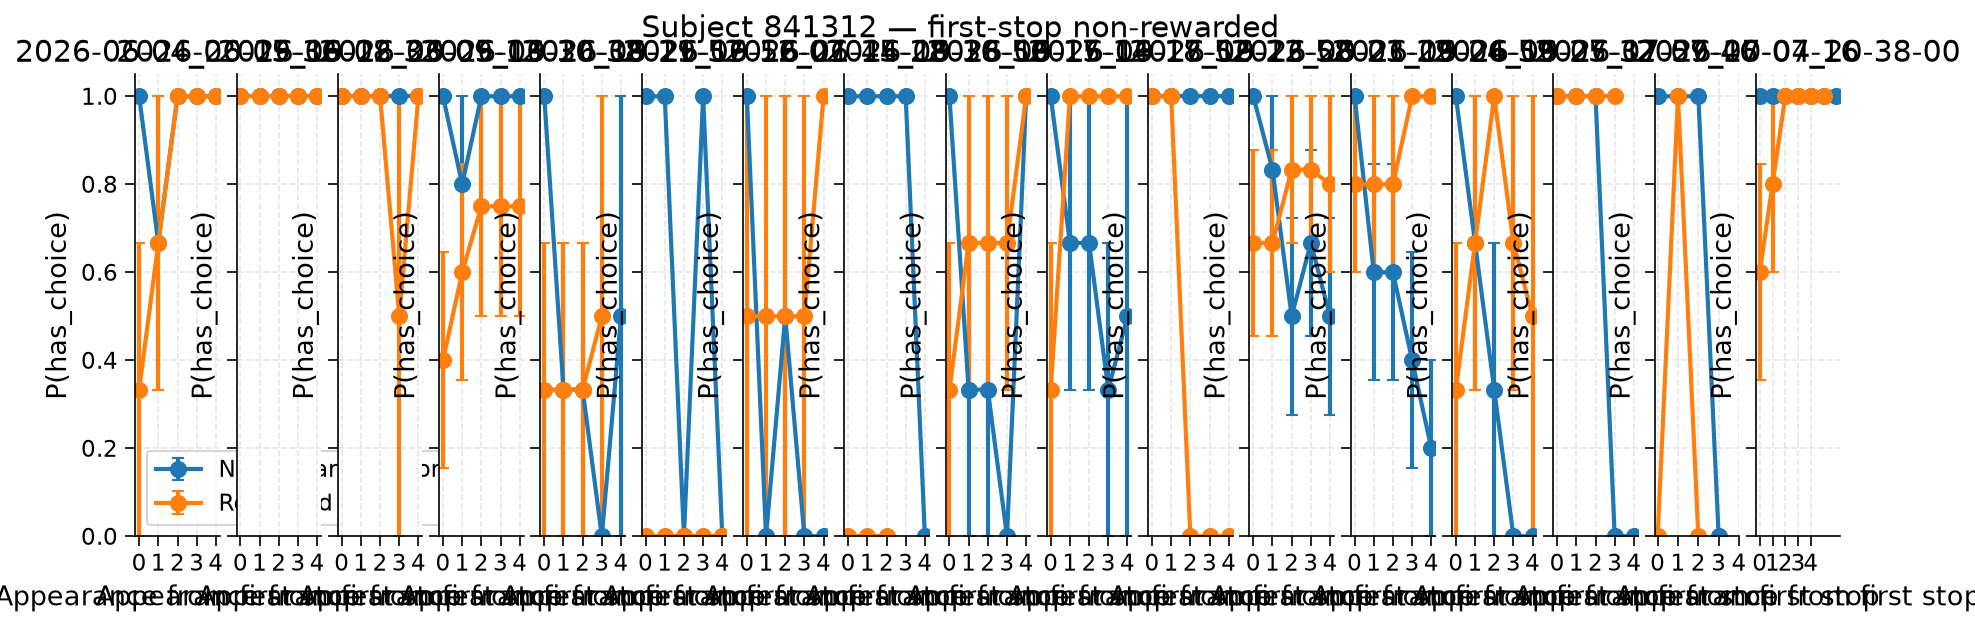

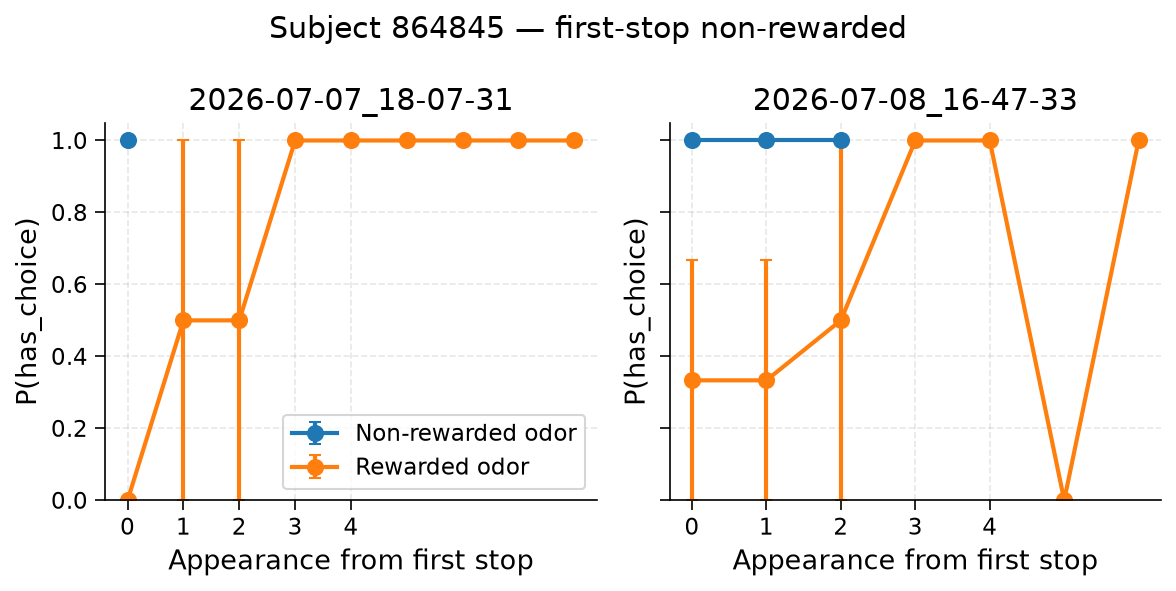

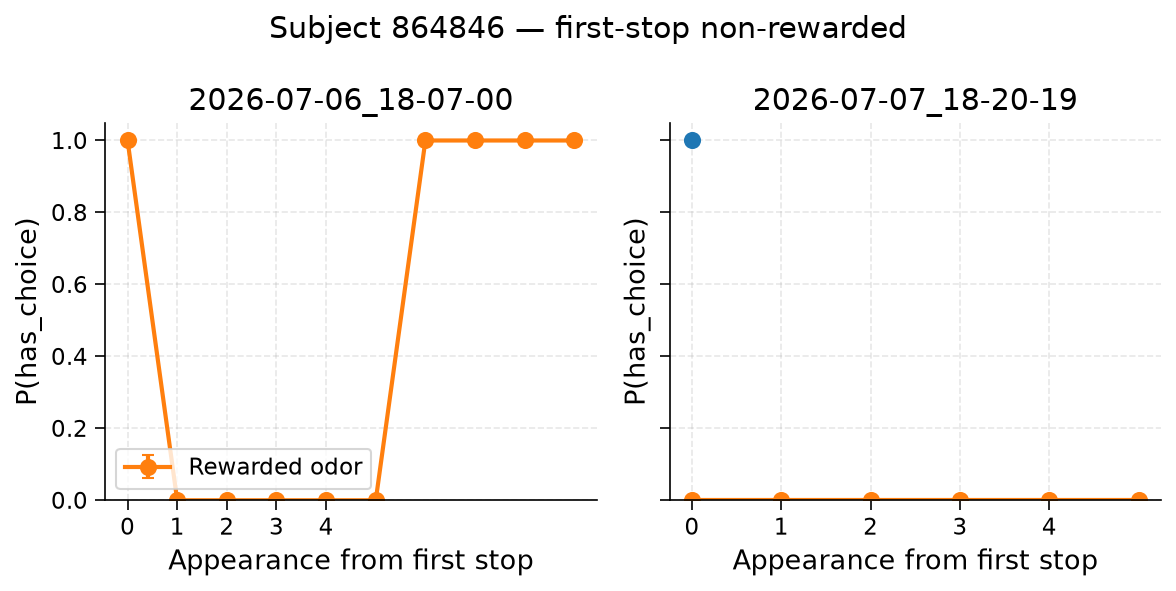

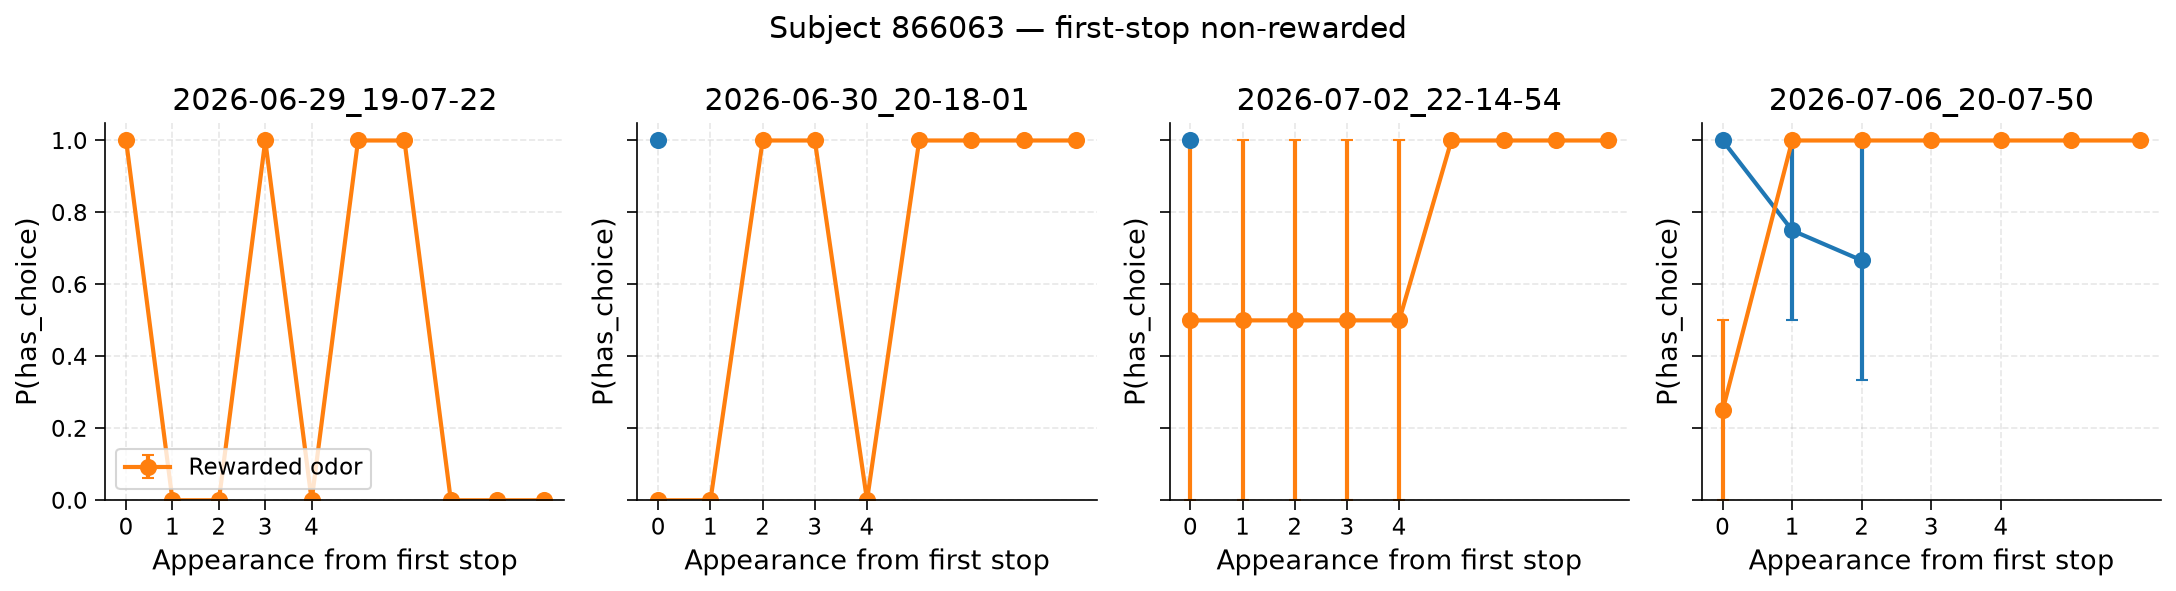

In [6]:
from helpers import plot_choice_by_block_position_by_first_stop

with a_lot_of_style():
    plot_choice_by_block_position_by_first_stop(trials)

plt.show()

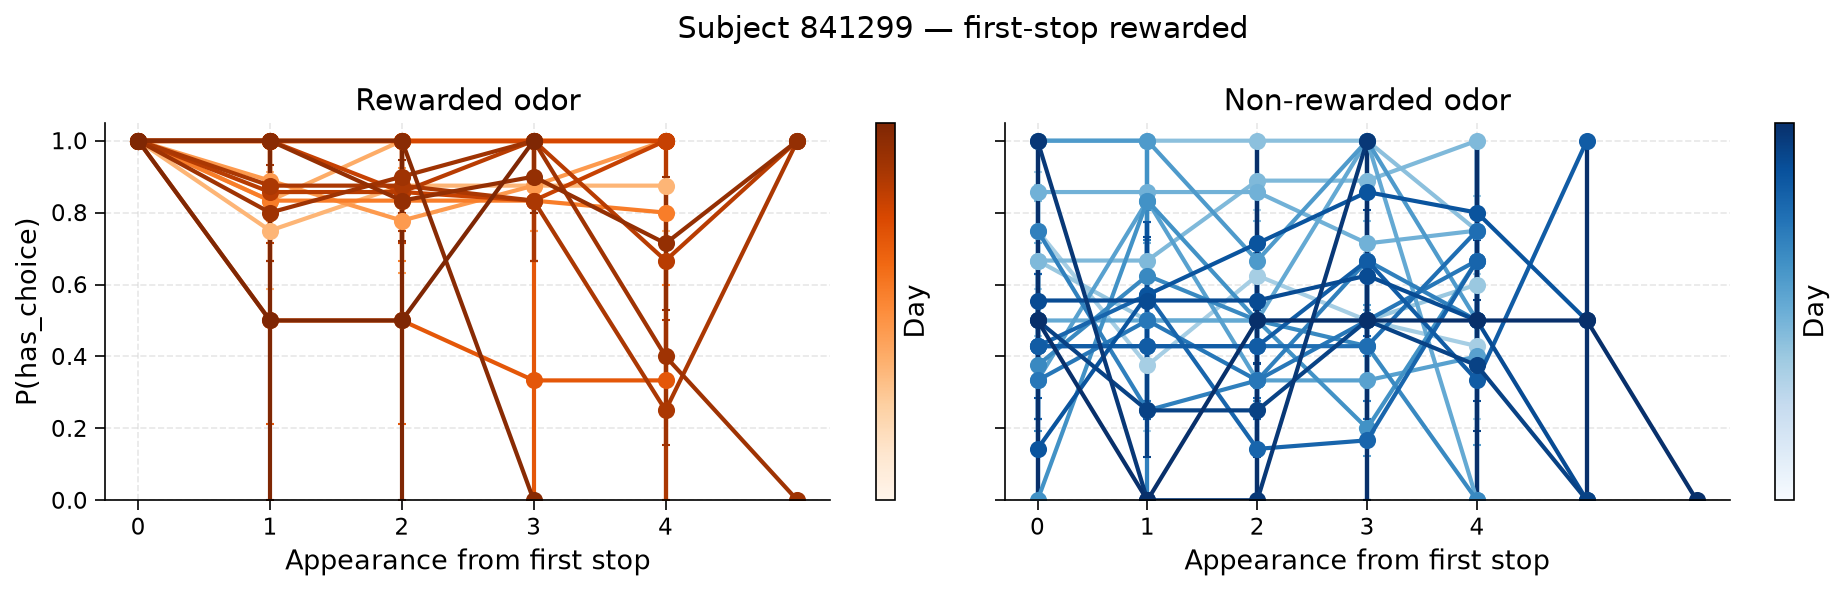

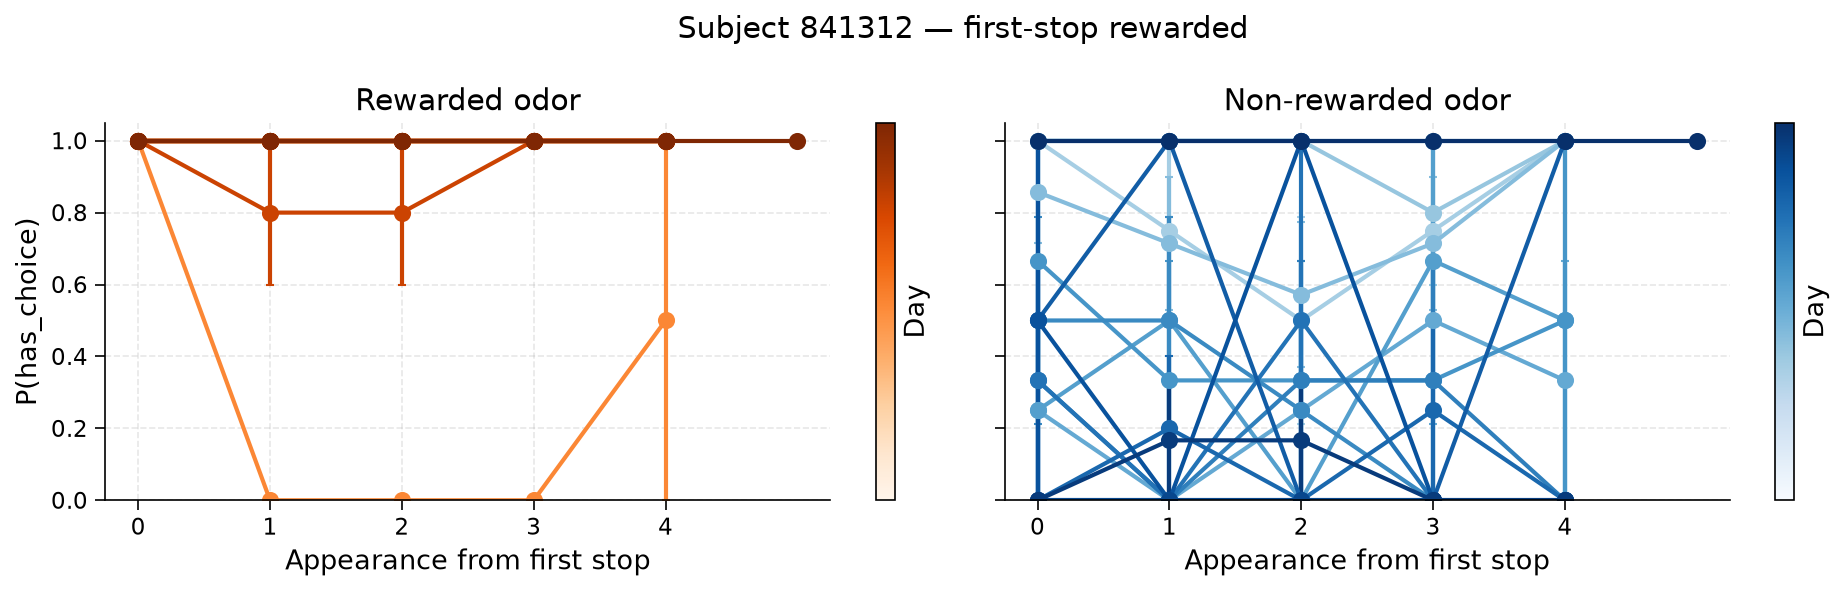

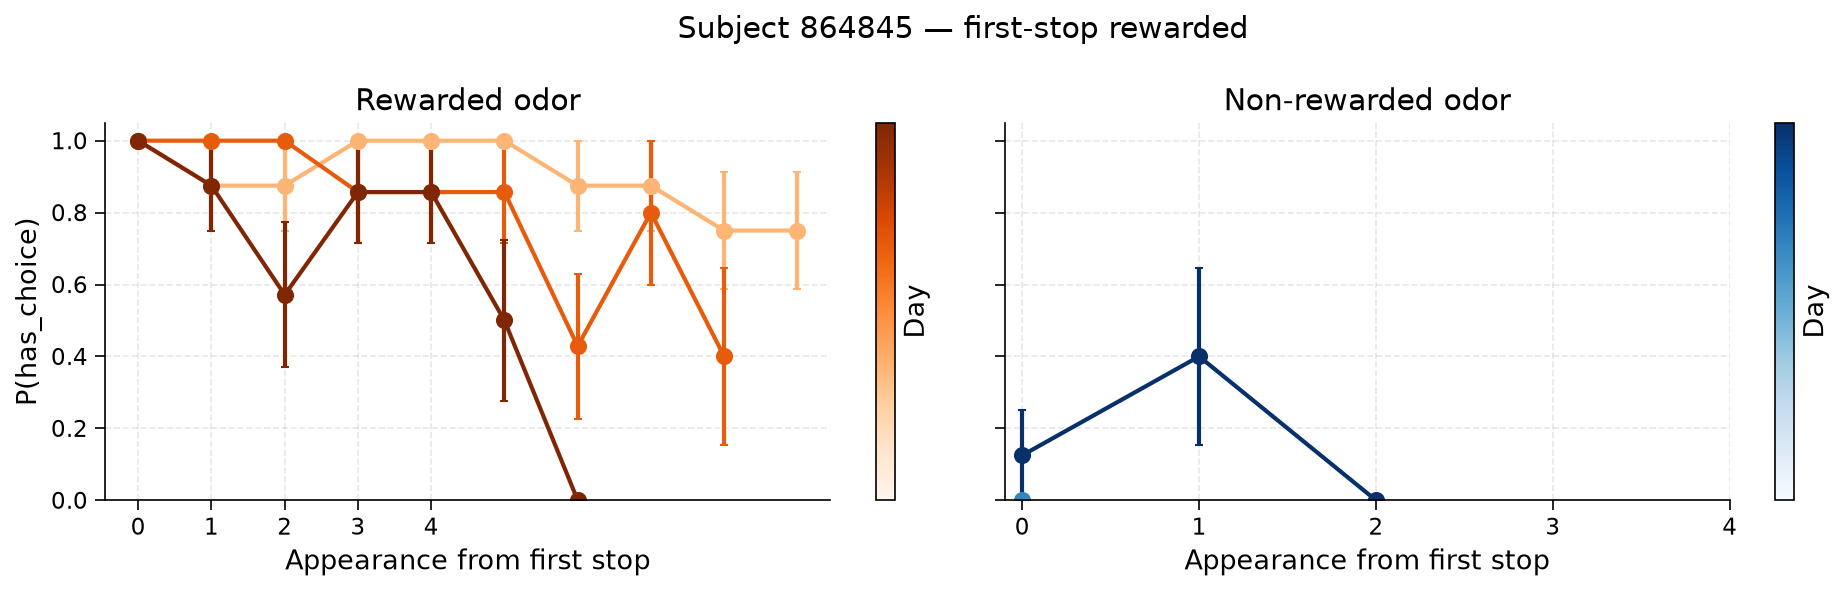

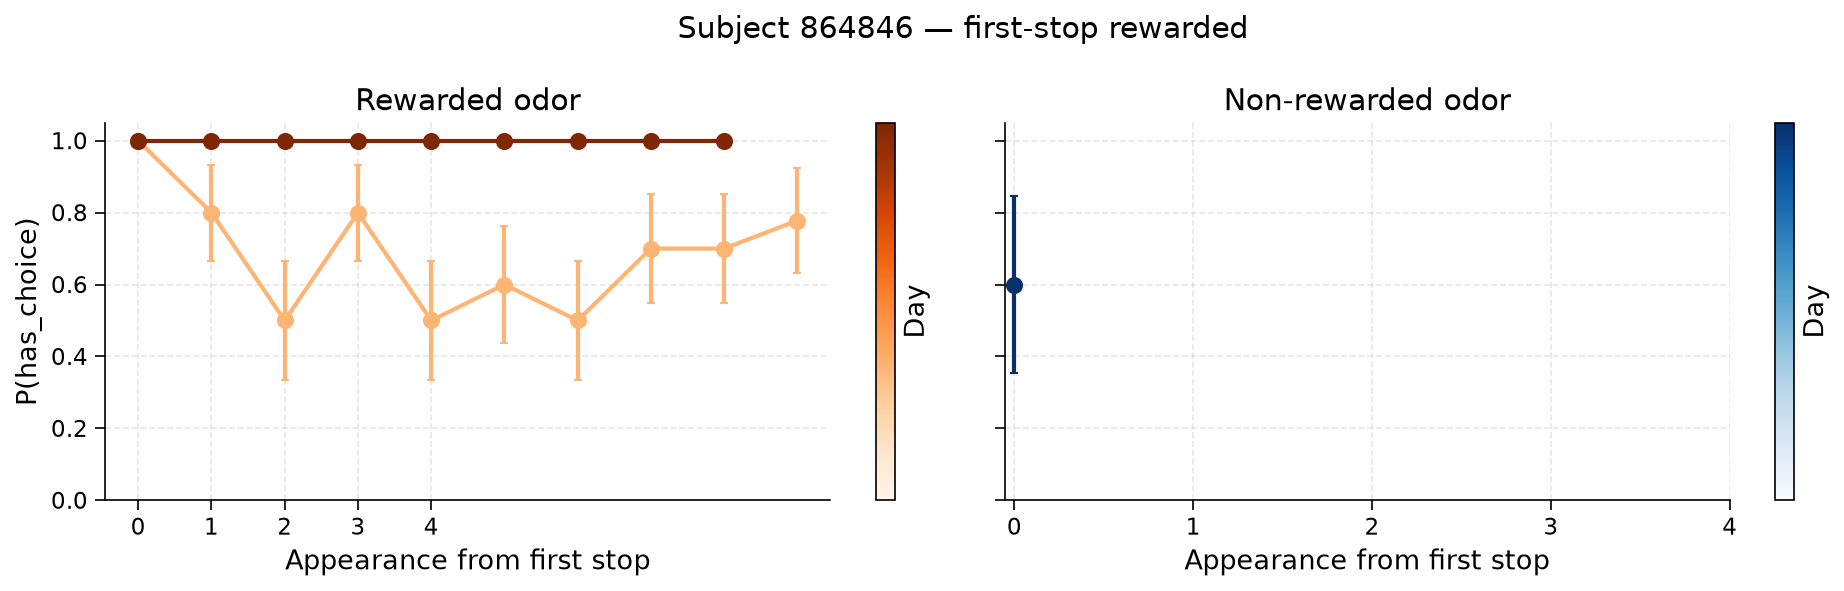

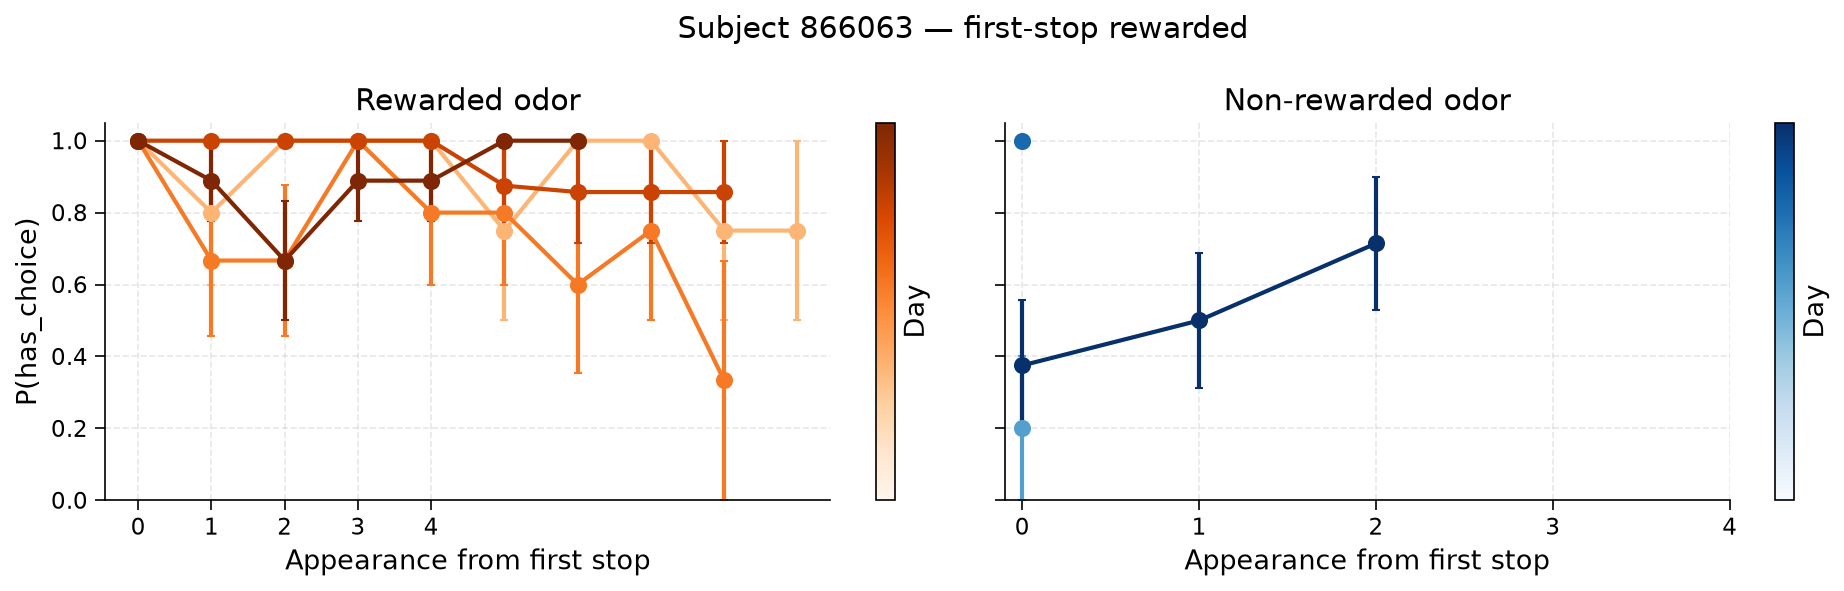

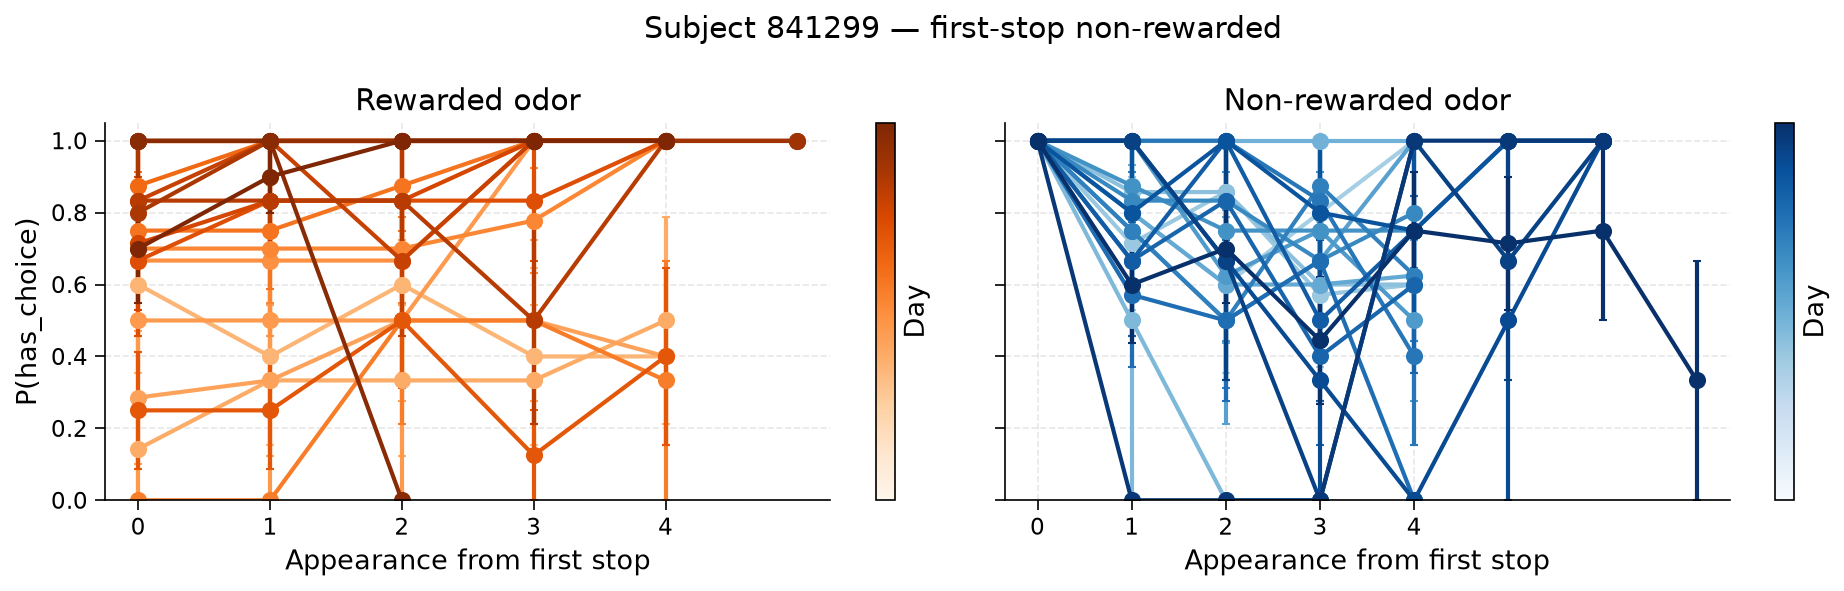

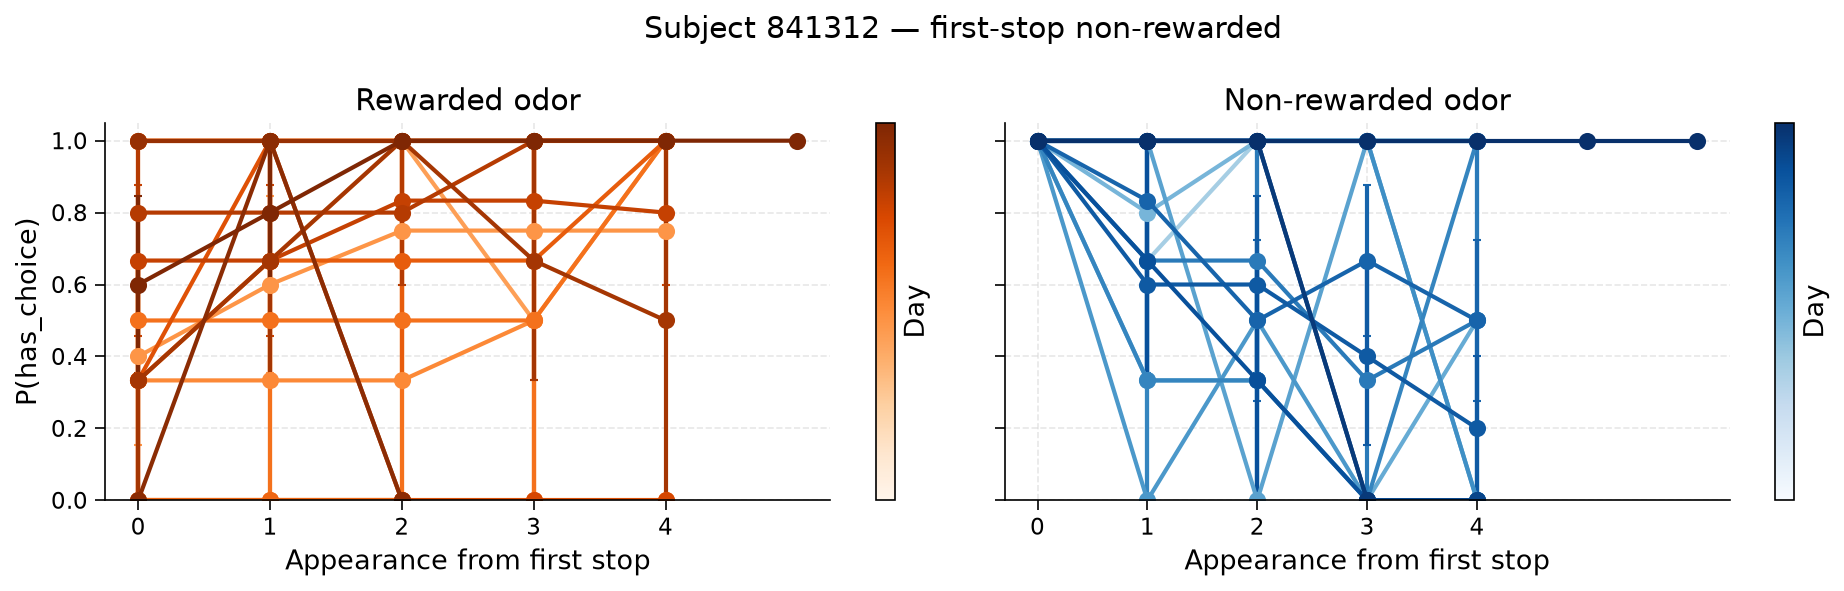

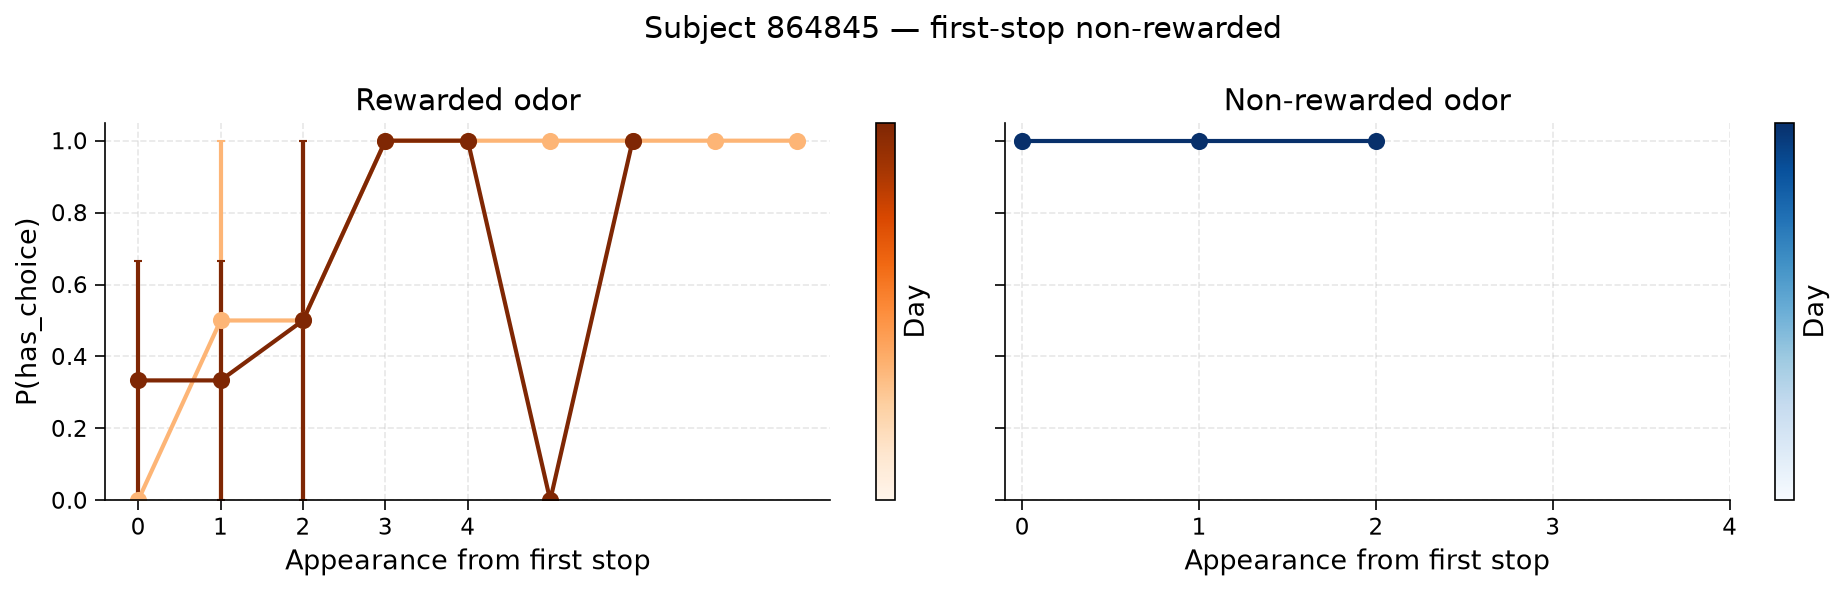

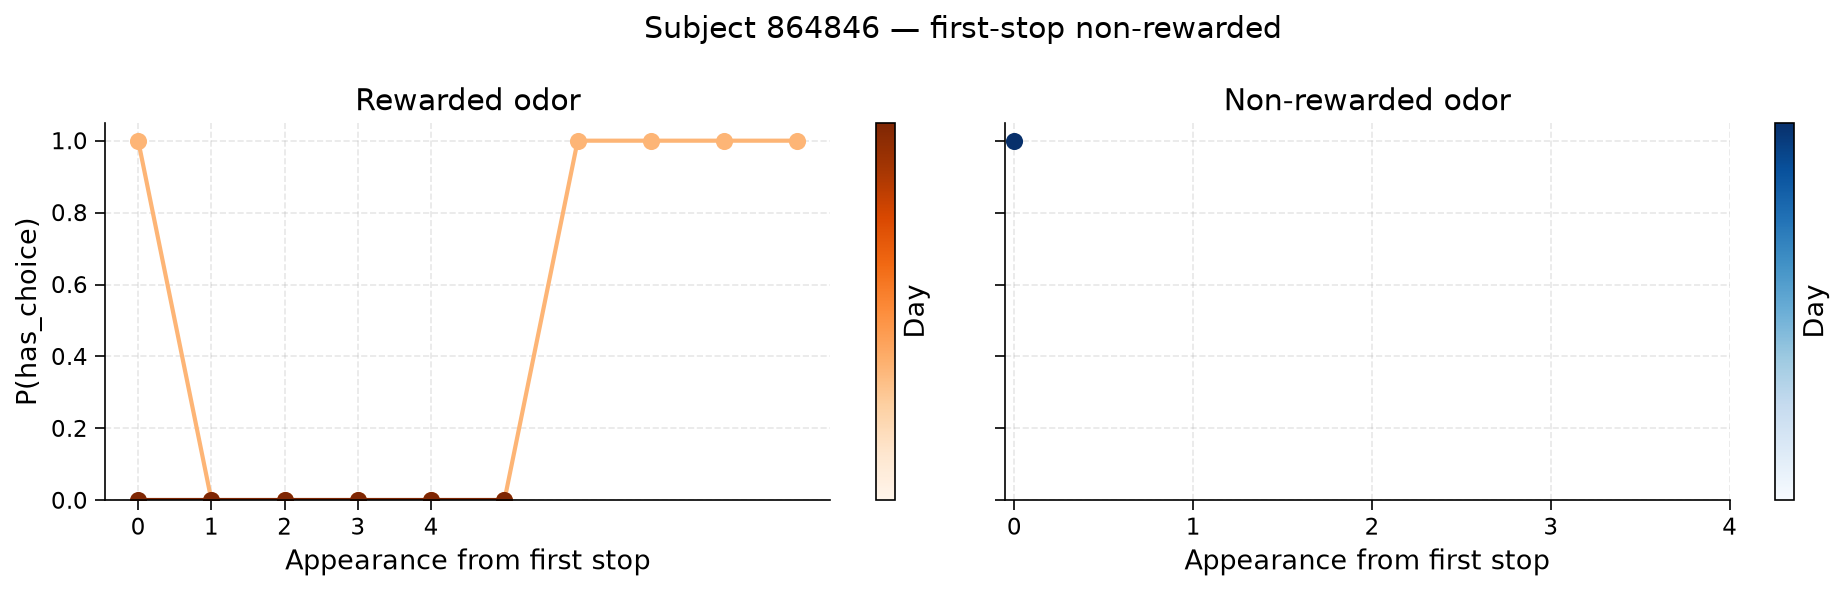

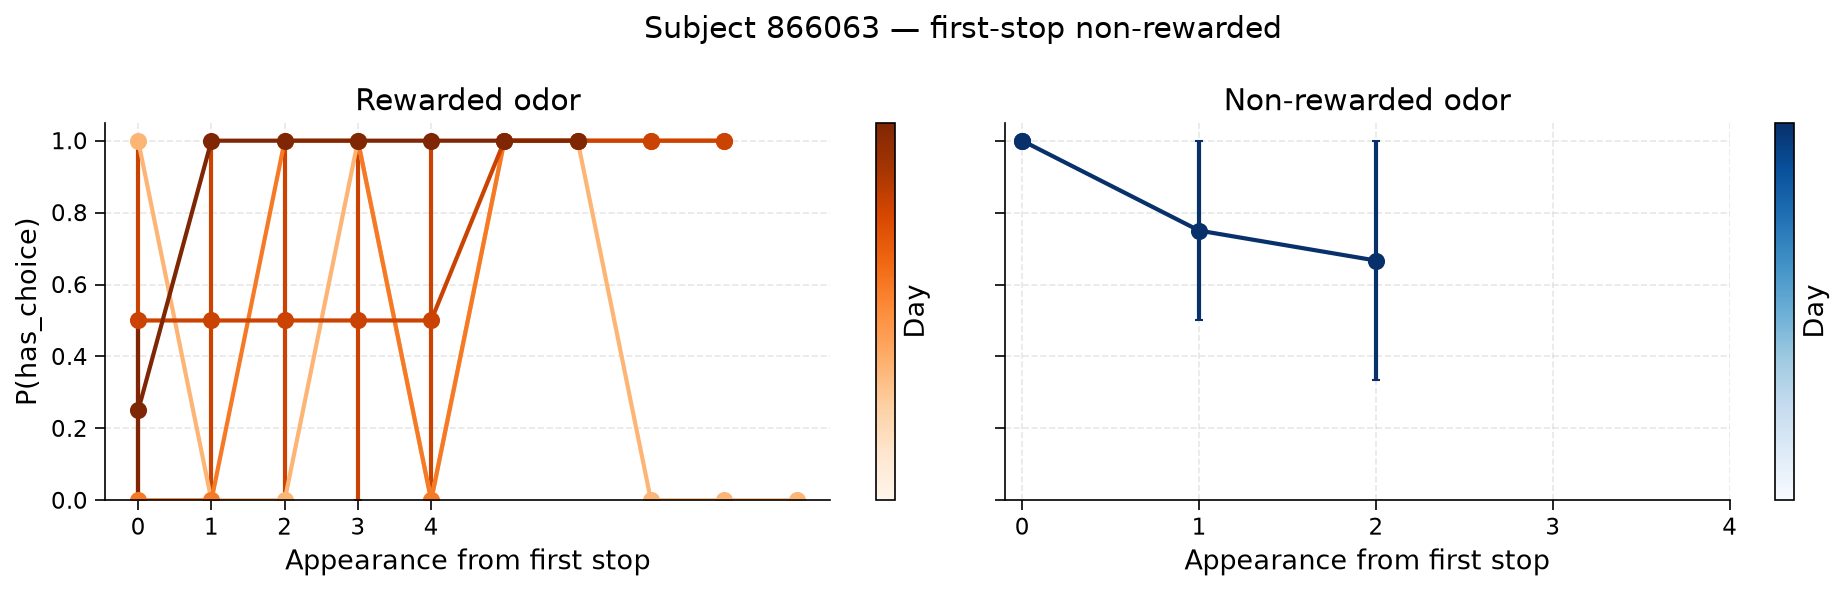

In [7]:
from helpers import plot_choice_by_block_position_by_first_stop_overlay

with a_lot_of_style():
    plot_choice_by_block_position_by_first_stop_overlay(trials)

plt.show()

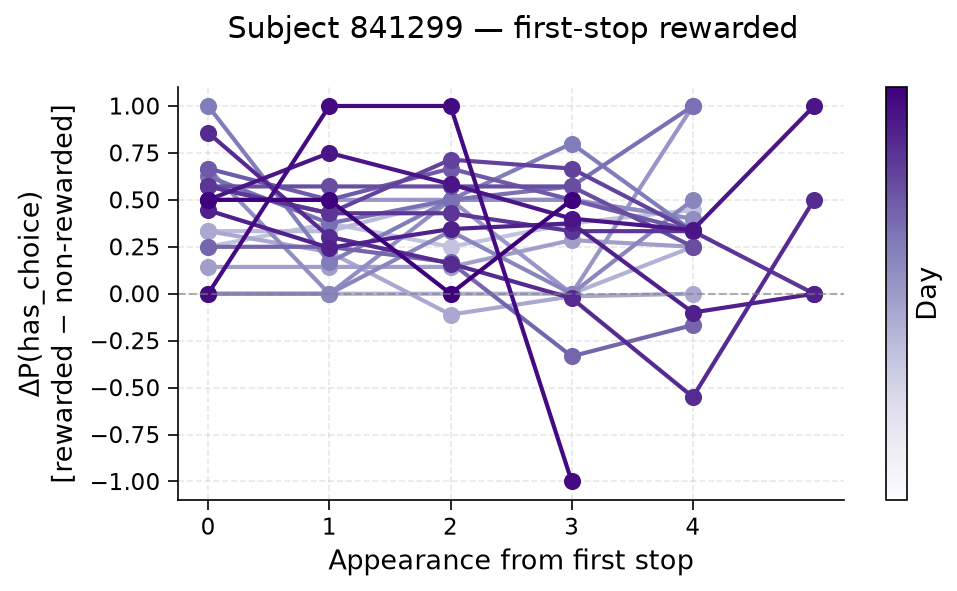

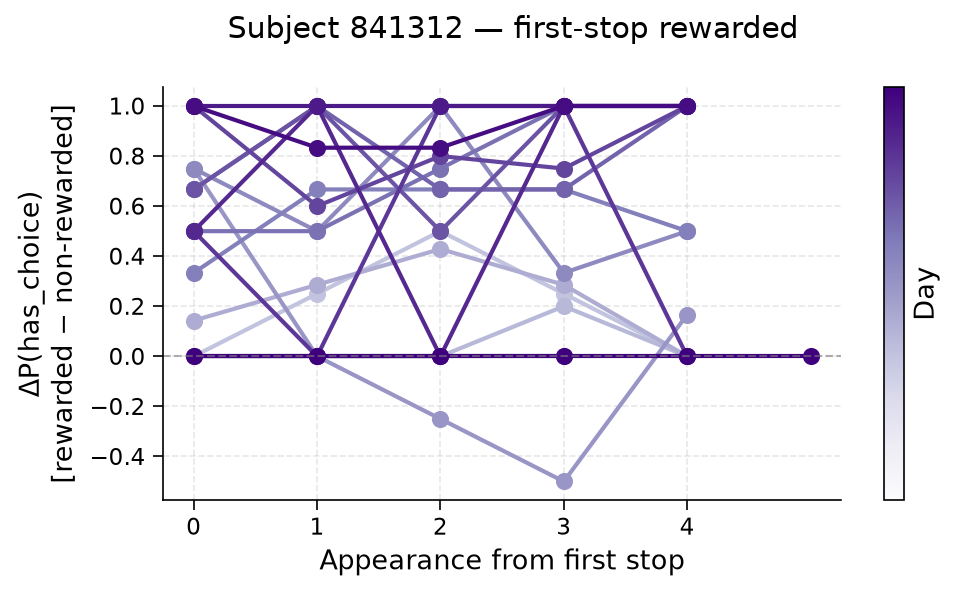

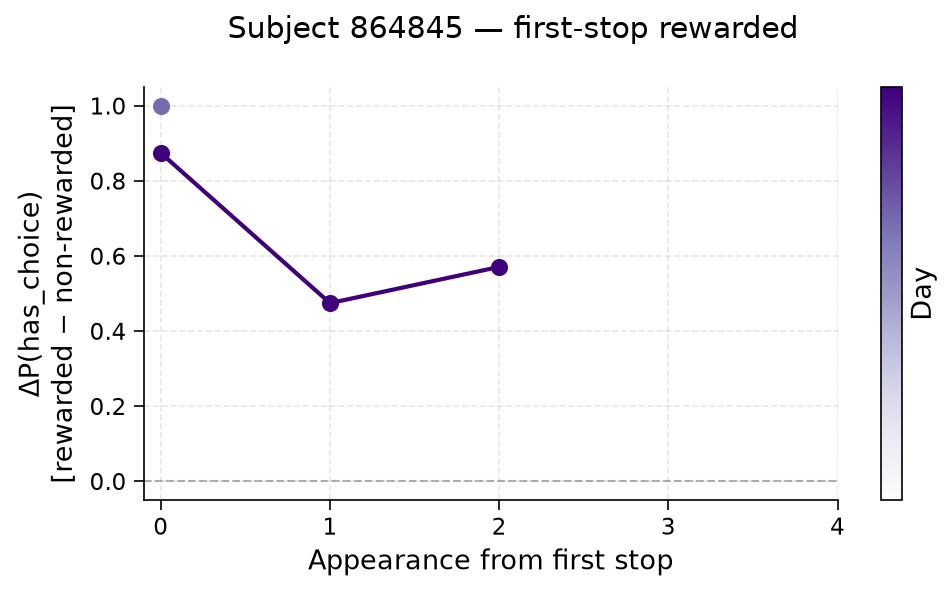

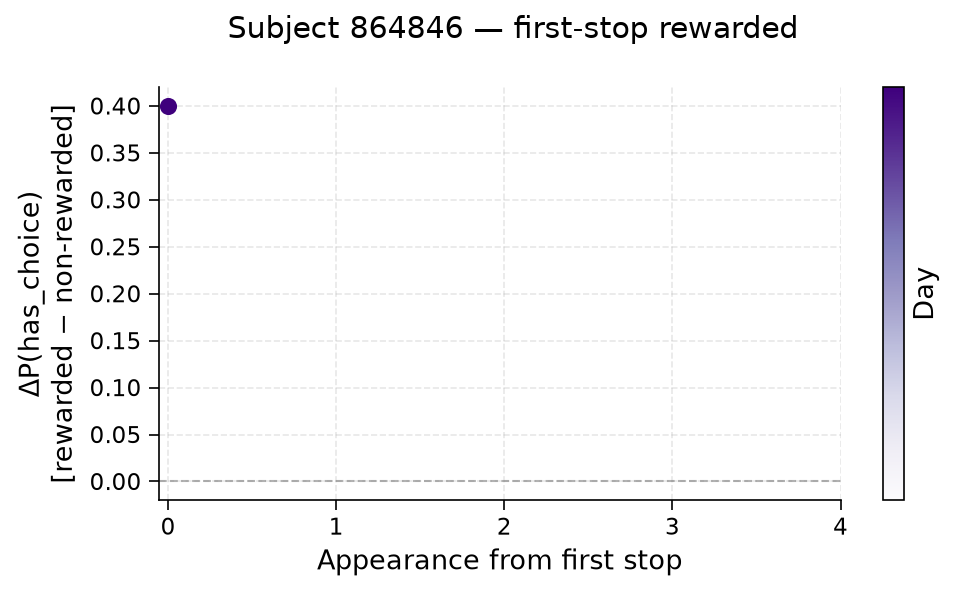

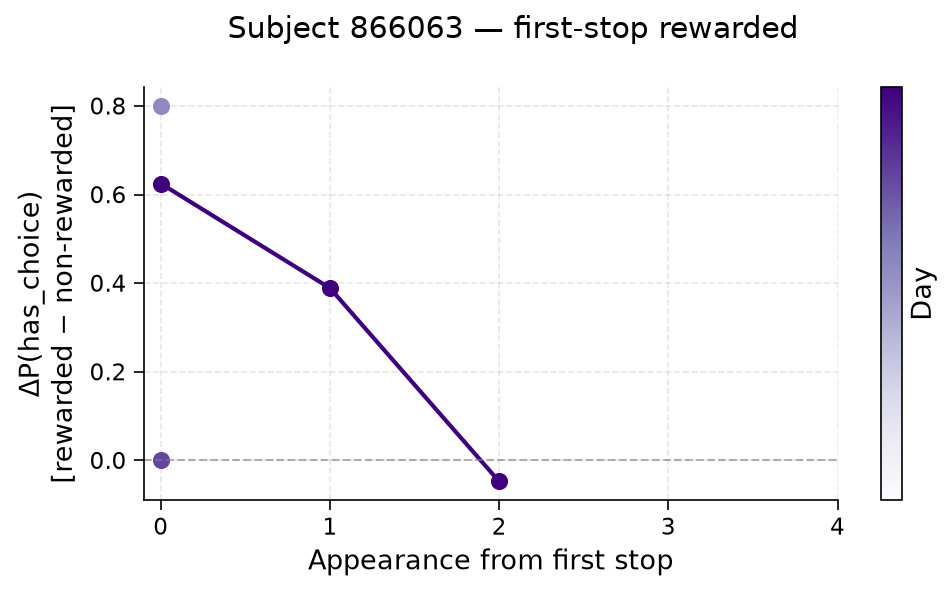

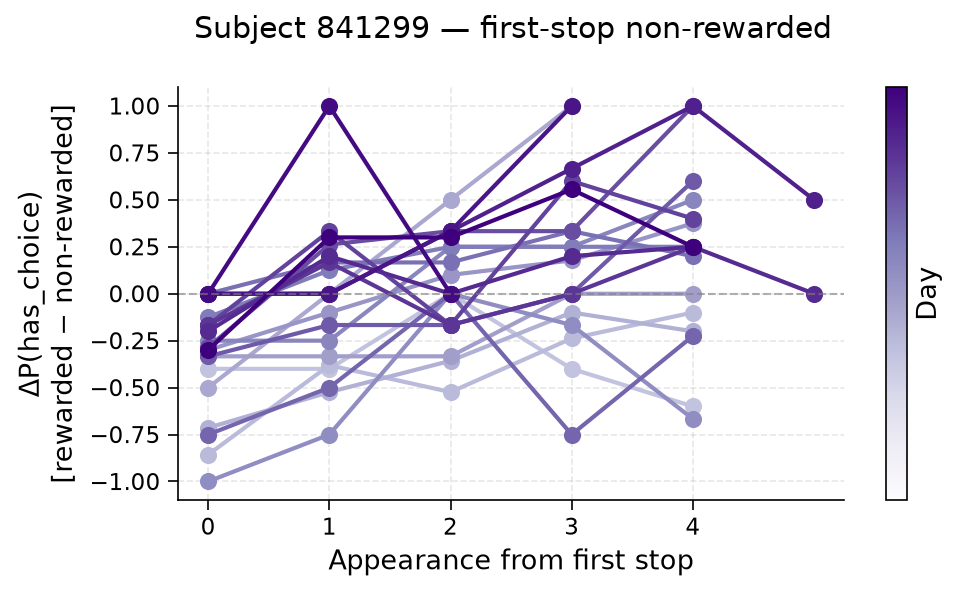

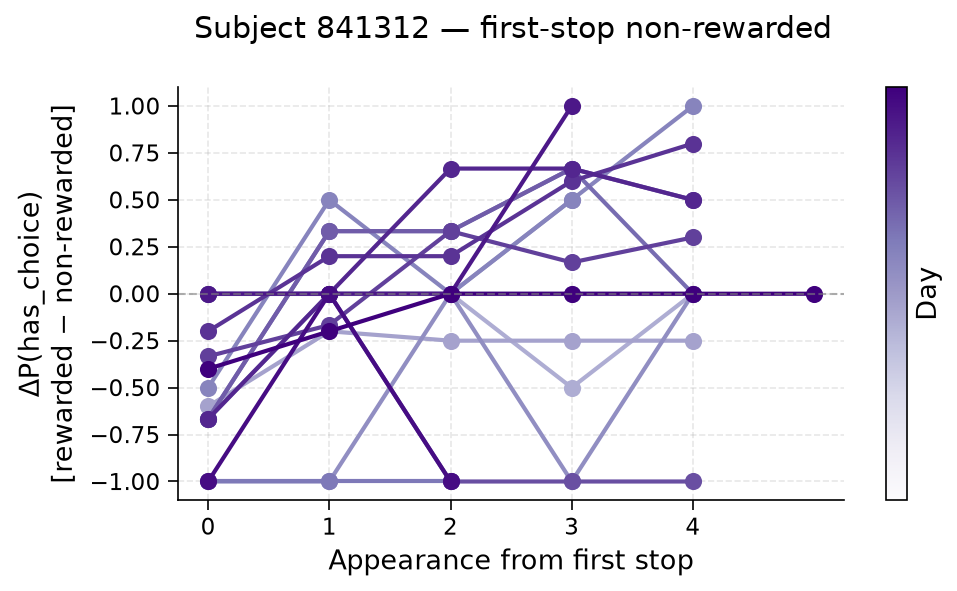

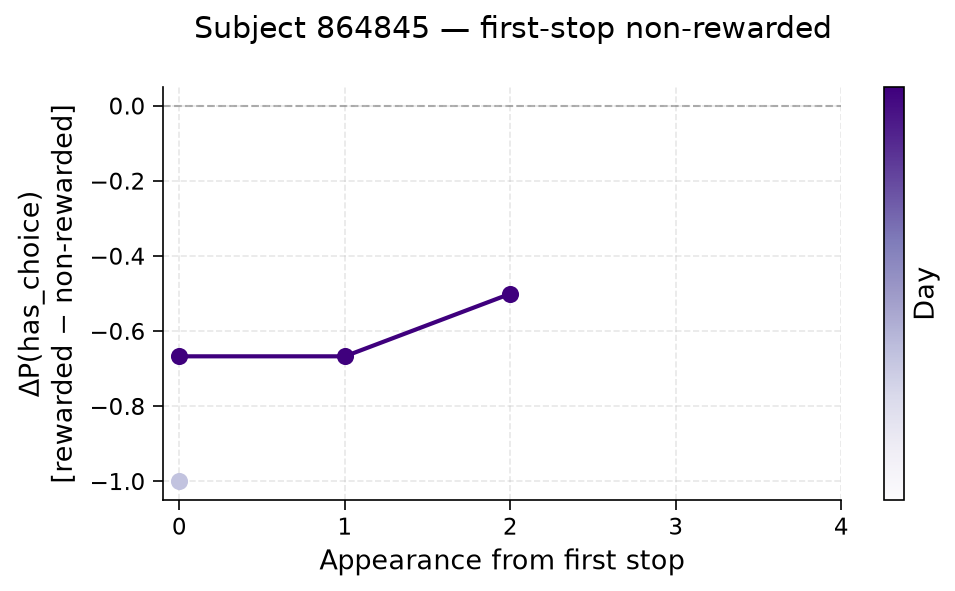

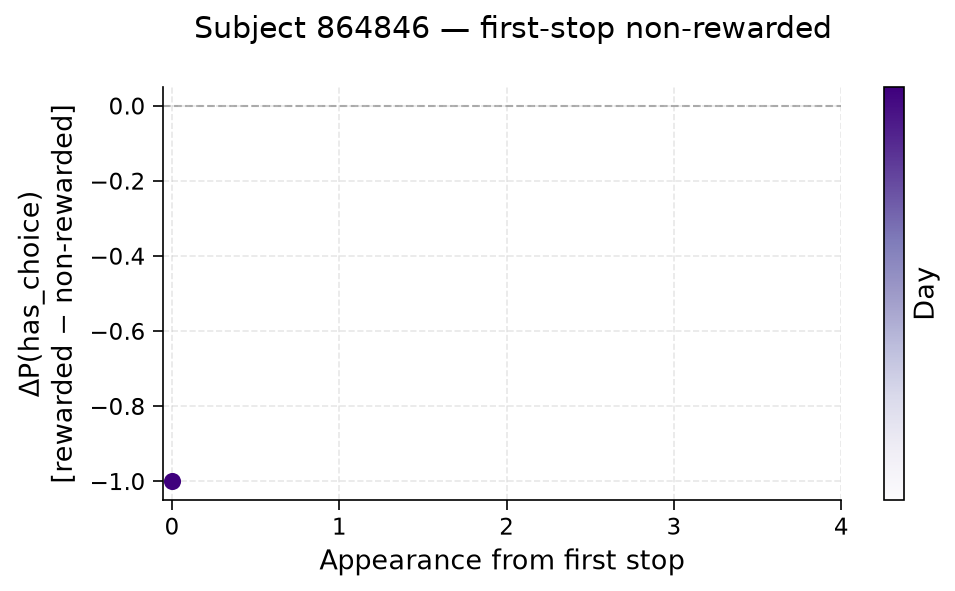

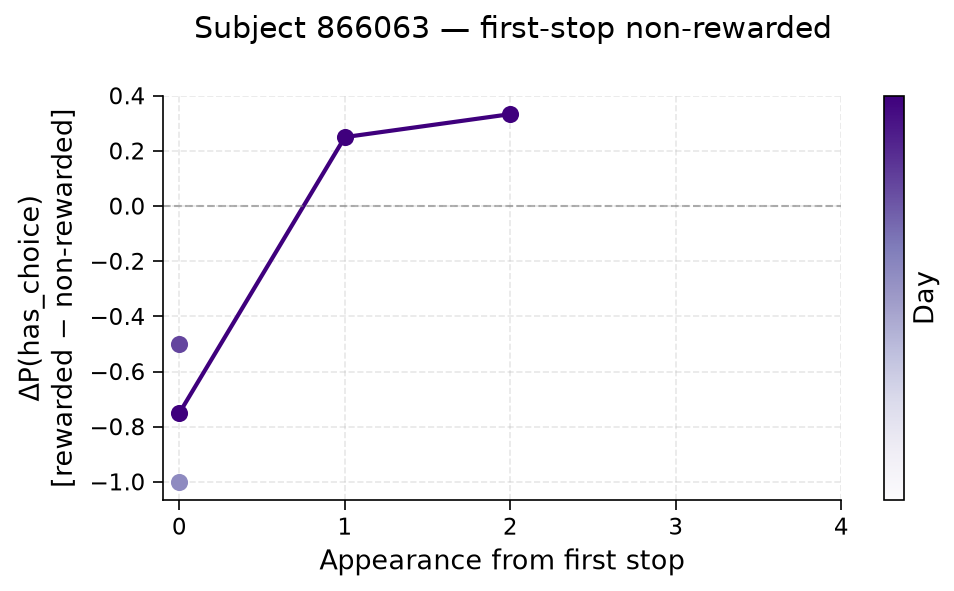

In [8]:
from helpers import plot_choice_difference_by_block_position_overlay

with a_lot_of_style():
    plot_choice_difference_by_block_position_overlay(trials)

plt.show()

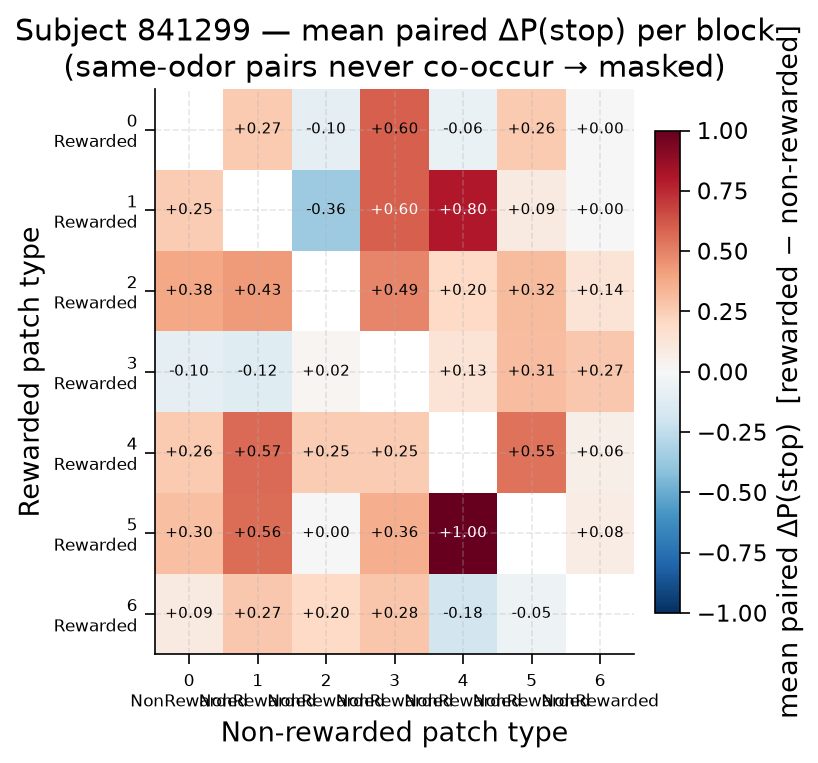

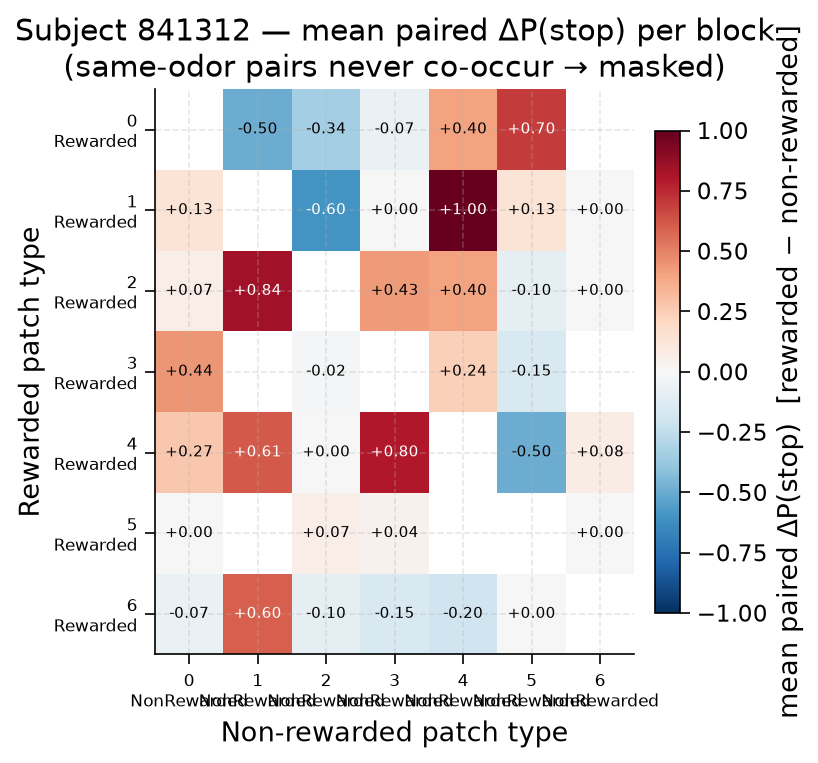

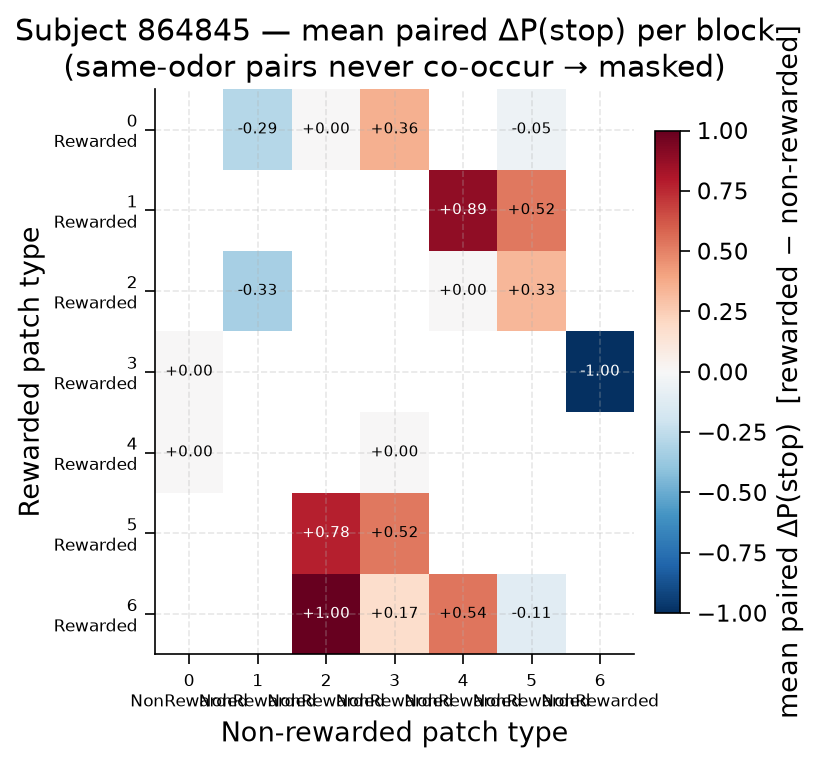

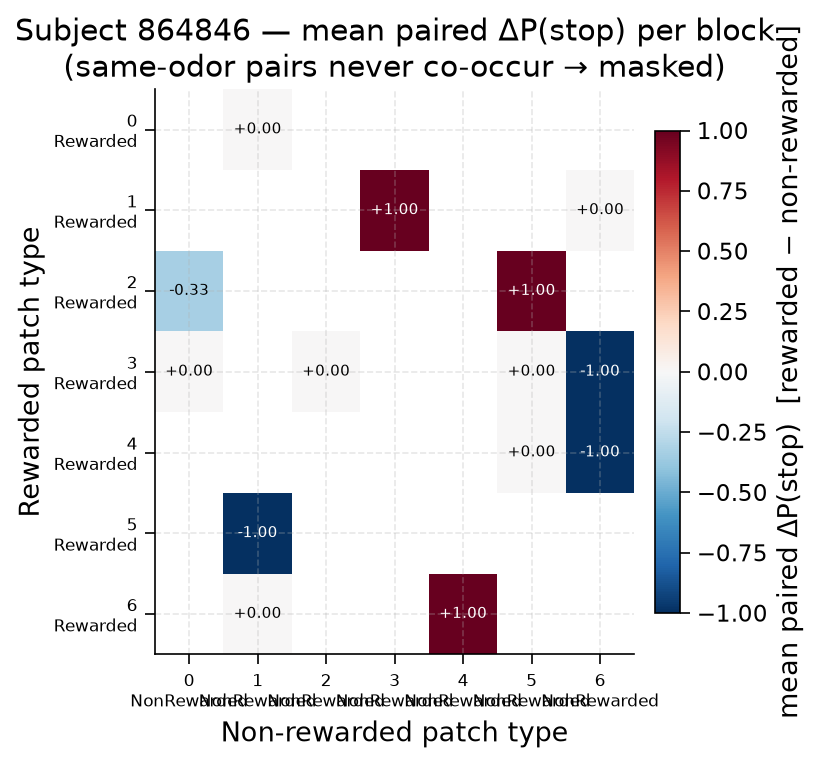

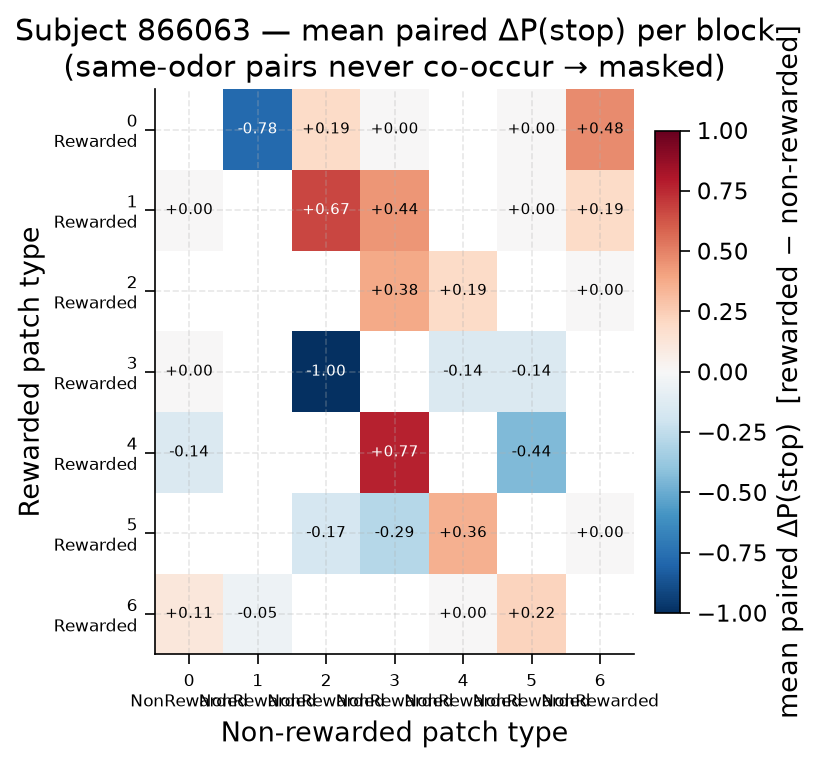

In [9]:
from helpers import plot_patch_type_delta_heatmap

with a_lot_of_style():
    plot_patch_type_delta_heatmap(trials)

plt.show()

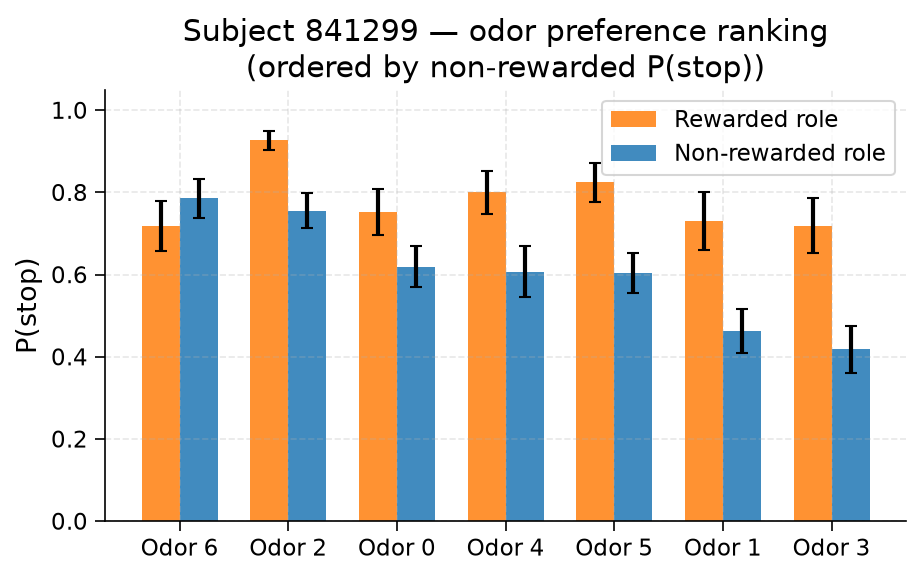

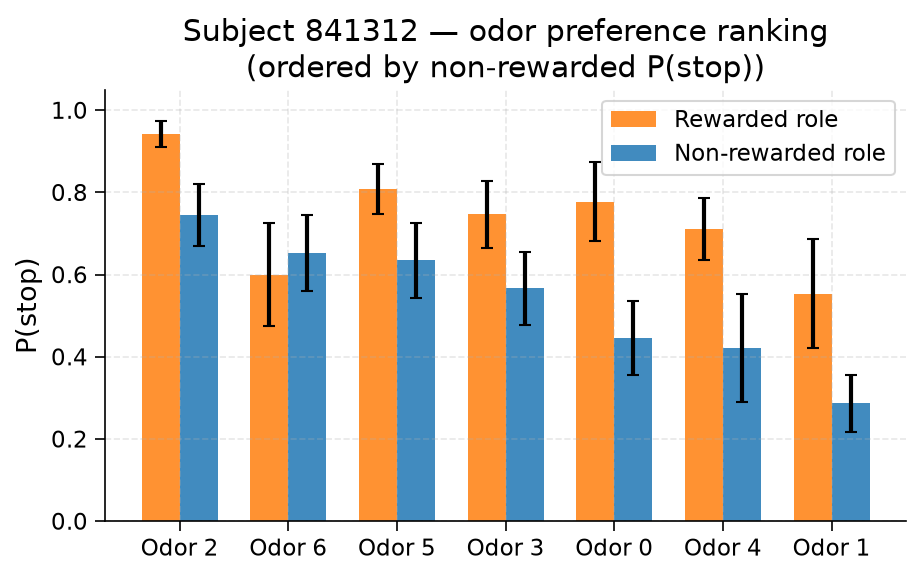

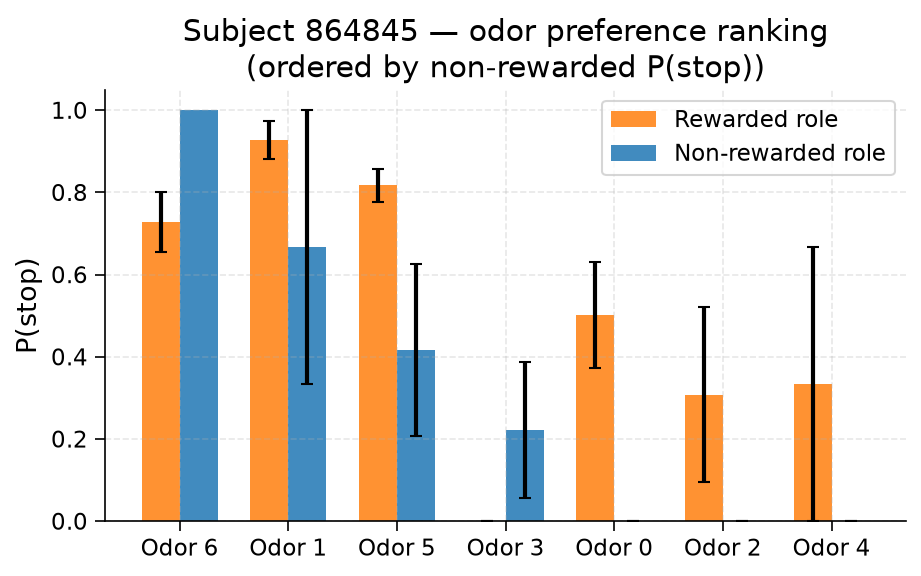

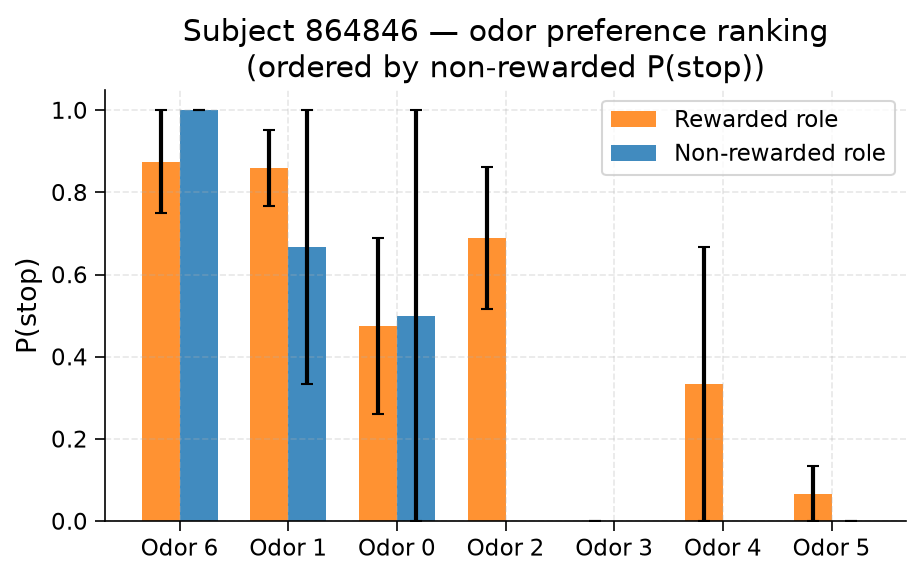

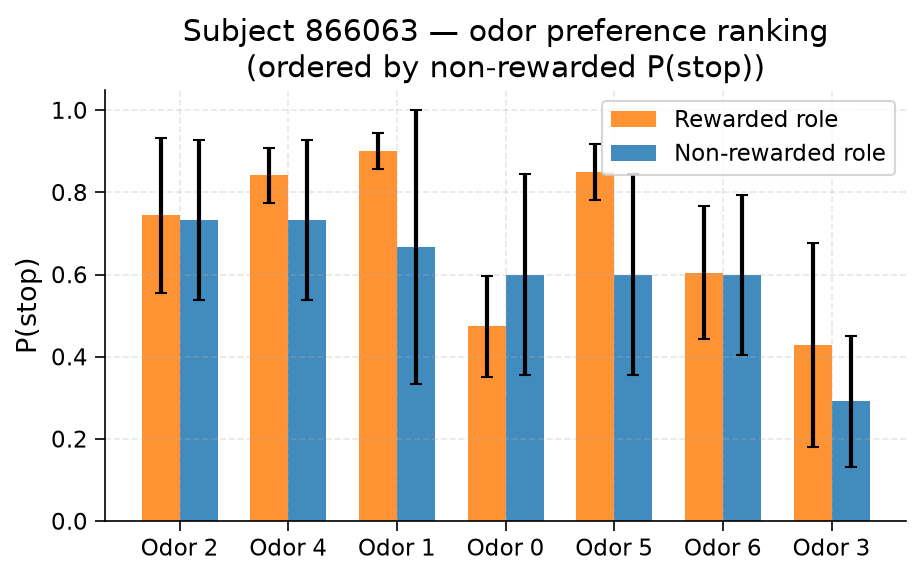

In [10]:
from helpers import plot_odor_preference_ranking

with a_lot_of_style():
    plot_odor_preference_ranking(trials)

plt.show()

ValueError: x and y must have same first dimension, but have shapes (16,) and (17,)

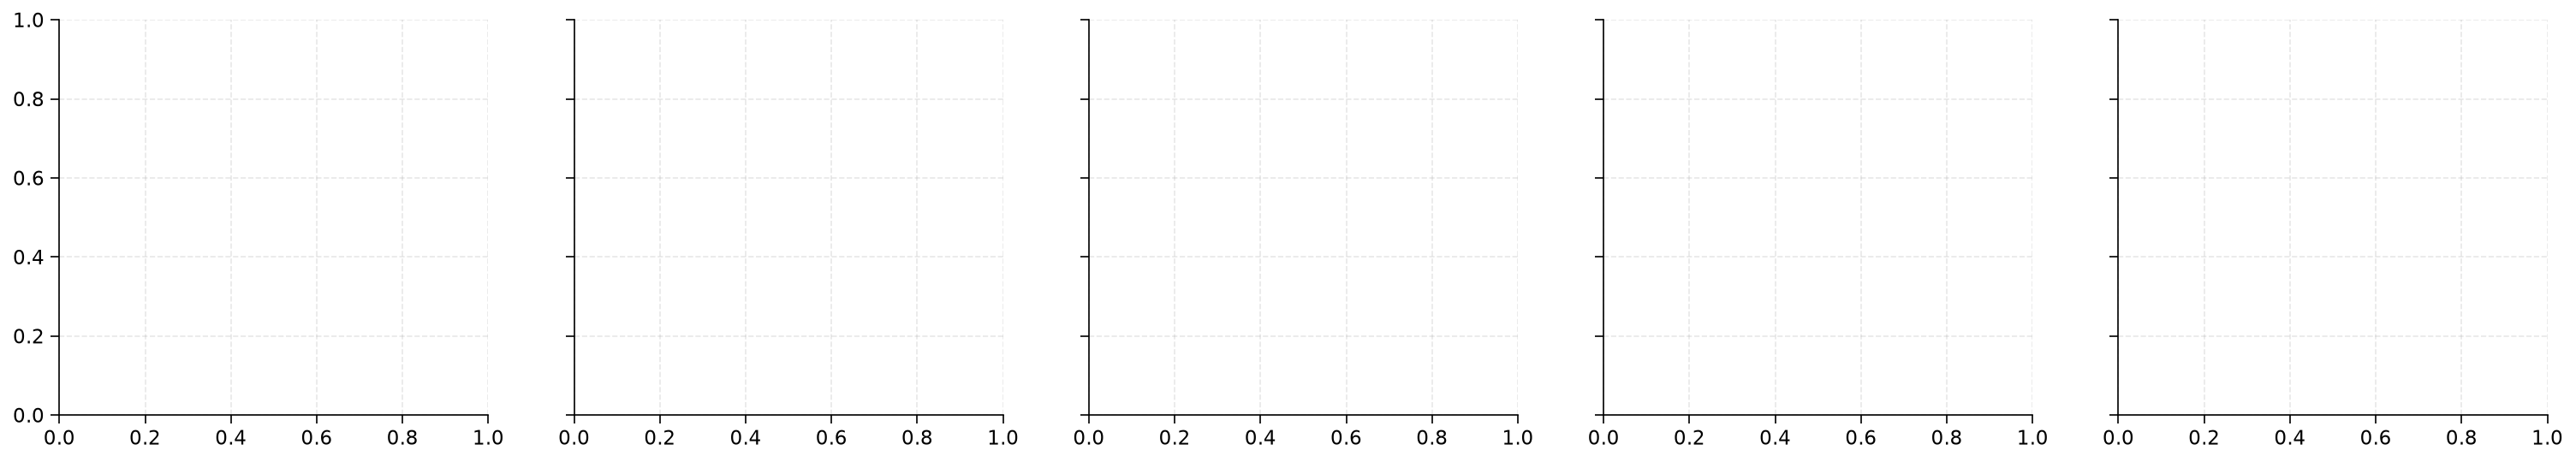

In [11]:

# P(choice) at the very first trial of every block, averaged within session, plotted across sessions

rs = trials[(trials["site_label"] == "RewardSite") & trials["block"].notna()].copy()
rs = rs.sort_values(["session_id", "block", "start_time"])

# Keep only the first trial of each block (position 0 within block)
rs["_block_pos"] = rs.groupby(["session_id", "block"]).cumcount()
first_trials = rs[rs["_block_pos"] == 0].copy()

# Add subject and session date label for plotting
first_trials["subject_id"] = first_trials["session_id"].str.split("_").str[0]
first_trials["session_date"] = first_trials["session_id"].str.split("_").str[1]

# Session-level average P(choice)
session_means = (
    first_trials.groupby(["subject_id", "session_id", "session_date"])["has_choice"]
    .mean()
    .reset_index()
)

with a_lot_of_style():
    fig, axes = plt.subplots(1, len(SUBJECT_IDS), figsize=(5 * len(SUBJECT_IDS), 4), sharey=True, squeeze=False)

    for ax, animal in zip(axes[0], SUBJECT_IDS):
        sub = session_means[session_means["subject_id"] == animal].sort_values("session_date")
        session_dates = sorted(sub["session_date"].unique())
        x = np.arange(len(session_dates))
        ax.plot(x, sub["has_choice"], marker="o", color="tab:blue")
        ax.set_xticks(x)
        ax.set_xticklabels(session_dates, rotation=45, ha="right")
        ax.set_xlabel("Session")
        ax.set_ylabel("P(choice) at first trial of block")
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Subject {animal}")

    fig.suptitle("P(choice) at first trial of each block (session averages)")
    fig.tight_layout()

plt.show()


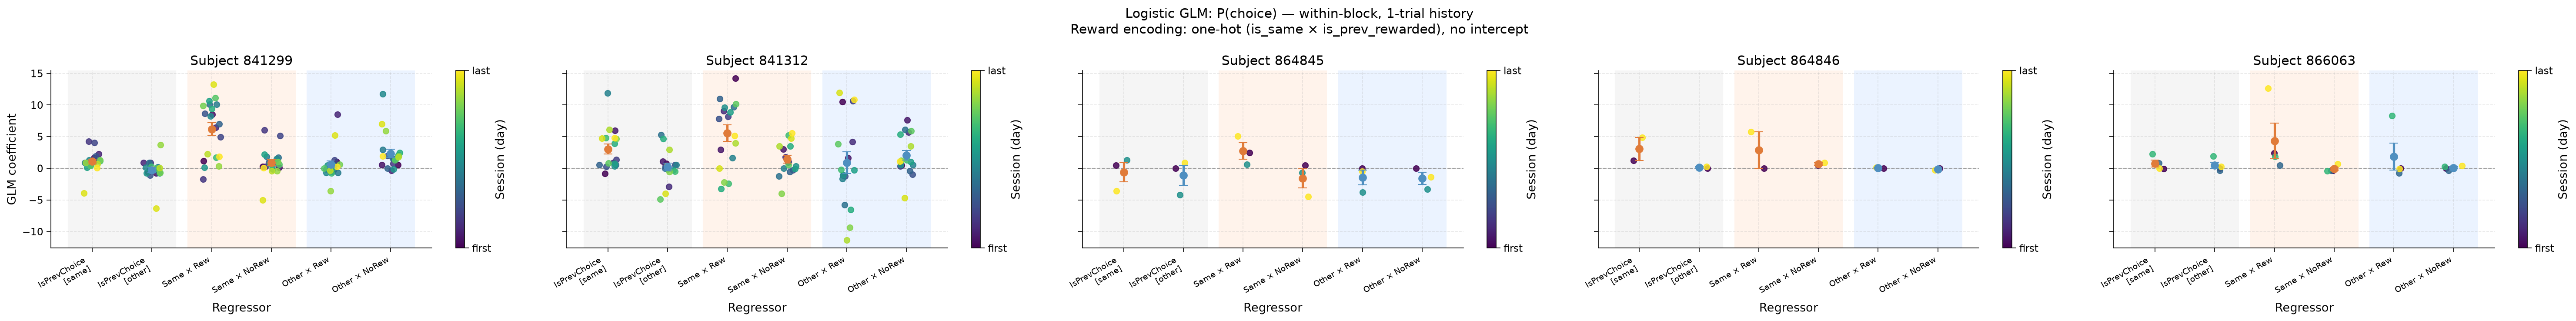

In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from viz_helpers import a_lot_of_style

# ── Build within-block, 1-trial-back feature table ──────────────────────────
rs = trials[(trials["site_label"] == "RewardSite") & trials["block"].notna()].copy()
rs = rs.sort_values(["session_id", "block", "start_time"])

grp = rs.groupby(["session_id", "block"], sort=False)
rs["prev_odor_index"] = grp["odor_index"].shift(1)
rs["prev_has_choice"] = grp["has_choice"].shift(1)
rs["prev_has_reward"]  = grp["has_reward"].shift(1)

rs = rs.dropna(subset=["prev_odor_index", "prev_has_choice", "prev_has_reward"])

# ── Regressors ───────────────────────────────────────────────────────────────
is_same       = (rs["odor_index"] == rs["prev_odor_index"]).to_numpy()
prev_choice   = rs["prev_has_choice"].astype(bool).to_numpy()
prev_rewarded = rs["prev_has_reward"].astype(bool).to_numpy()

# IsPrevChoice split by same/other (±1 coding, zero on off-condition)
rs["IsPrevChoice_SameOdor"]  = np.where(is_same,  np.where(prev_choice, 1.0, -1.0), 0.0)
rs["IsPrevChoice_OtherOdor"] = np.where(~is_same, np.where(prev_choice, 1.0, -1.0), 0.0)

# Full one-hot cross of is_same × is_prev_rewarded (all 4 cells, no intercept)
#
#   is_same │ is_prev_rewarded │ indicator
#   ────────┼──────────────────┼──────────────────
#     0     │       0          │ H_Other_NoRew
#     0     │       1          │ H_Other_Rew
#     1     │       0          │ H_Same_NoRew
#     1     │       1          │ H_Same_Rew
rs["H_Same_Rew"]    = ( is_same &  prev_rewarded).astype(float)
rs["H_Same_NoRew"]  = ( is_same & ~prev_rewarded).astype(float)
rs["H_Other_Rew"]   = (~is_same &  prev_rewarded).astype(float)
rs["H_Other_NoRew"] = (~is_same & ~prev_rewarded).astype(float)

rs["choice"] = rs["has_choice"].astype(int)

PLOT_COEFS = [
    "IsPrevChoice_SameOdor",
    "IsPrevChoice_OtherOdor",
    "H_Same_Rew",
    "H_Same_NoRew",
    "H_Other_Rew",
    "H_Other_NoRew",
]
FEATURE_COLS = PLOT_COEFS

# ── Fit logistic GLM per session (no intercept, all 4 one-hot cells) ─────────
records = []
for session_id, sdf in rs.groupby("session_id"):
    if len(sdf) < 10 or sdf["choice"].nunique() < 2:
        continue
    X = sdf[FEATURE_COLS].to_numpy(dtype=float)
    y = sdf["choice"].to_numpy(dtype=int)
    try:
        clf = LogisticRegression(C=np.inf, solver="lbfgs", fit_intercept=False, max_iter=500)
        clf.fit(X, y)
        for name, val in zip(PLOT_COEFS, clf.coef_[0]):
            records.append(dict(
                session_id=session_id,
                subject_id=session_id.split("_")[0],
                coef=name,
                value=val,
            ))
    except Exception as e:
        print(f"Session {session_id} failed: {e}")

coefs = pd.DataFrame(records)

# ── Colour scheme ─────────────────────────────────────────────────────────────
SAME_COLOR    = "#e07b39"
OTHER_COLOR   = "#4f8fc0"
NEUTRAL_COLOR = "gray"

def _coef_color(name):
    if name.startswith("H_Same"):  return SAME_COLOR
    if name.startswith("H_Other"): return OTHER_COLOR
    if "Same" in name:             return SAME_COLOR
    if "Other" in name:            return OTHER_COLOR
    return NEUTRAL_COLOR

TICK_LABELS = [
    "IsPrevChoice\n[same]",
    "IsPrevChoice\n[other]",
    "Same × Rew",
    "Same × NoRew",
    "Other × Rew",
    "Other × NoRew",
]

subjects  = sorted(coefs["subject_id"].unique())
x_pos     = np.arange(len(PLOT_COEFS))
rng       = np.random.default_rng(0)

PAIR_GROUPS = [
    (["IsPrevChoice_SameOdor", "IsPrevChoice_OtherOdor"], "#f5f5f5"),
    (["H_Same_Rew", "H_Same_NoRew"],   "#fff3eb"),
    (["H_Other_Rew", "H_Other_NoRew"], "#ebf3ff"),
]

with a_lot_of_style():
    fig, axes = plt.subplots(
        1, len(subjects),
        figsize=(8 * len(subjects), 5),
        sharey=True,
        squeeze=False,
    )

    for ax, subject in zip(axes[0], subjects):
        for group_members, bg in PAIR_GROUPS:
            idxs = [PLOT_COEFS.index(m) for m in group_members]
            ax.axvspan(min(idxs) - 0.4, max(idxs) + 0.4, color=bg, zorder=0)

        sub      = coefs[coefs["subject_id"] == subject]
        sessions = sorted(sub["session_id"].unique())
        n        = len(sessions)
        cmap     = plt.get_cmap("viridis")
        norm     = Normalize(vmin=0, vmax=max(n - 1, 1))

        for day, session_id in enumerate(sessions):
            sdata = sub[sub["session_id"] == session_id].set_index("coef")["value"]
            vals  = [sdata.get(c, np.nan) for c in PLOT_COEFS]
            jx    = x_pos + rng.uniform(-0.15, 0.15, len(x_pos))
            ax.scatter(jx, vals, color=cmap(norm(day)), s=40, zorder=3, alpha=0.85)

        means = sub.groupby("coef")["value"].mean().reindex(PLOT_COEFS)
        sems  = sub.groupby("coef")["value"].sem().reindex(PLOT_COEFS)
        for xi, coef in enumerate(PLOT_COEFS):
            ax.errorbar(xi, means[coef], yerr=sems[coef],
                        fmt="o", color=_coef_color(coef), ms=8, lw=2.5, capsize=5, zorder=5)

        ax.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(TICK_LABELS, rotation=30, ha="right", fontsize=9)
        ax.set_title(f"Subject {subject}")
        ax.set_xlabel("Regressor")

        cb = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax)
        cb.set_label("Session (day)")
        cb.set_ticks([0, max(n - 1, 1)])
        cb.set_ticklabels(["first", "last"])

    axes[0][0].set_ylabel("GLM coefficient")
    fig.suptitle("Logistic GLM: P(choice) — within-block, 1-trial history\n"
                 "Reward encoding: one-hot (is_same × is_prev_rewarded), no intercept")
    fig.tight_layout()

plt.show()


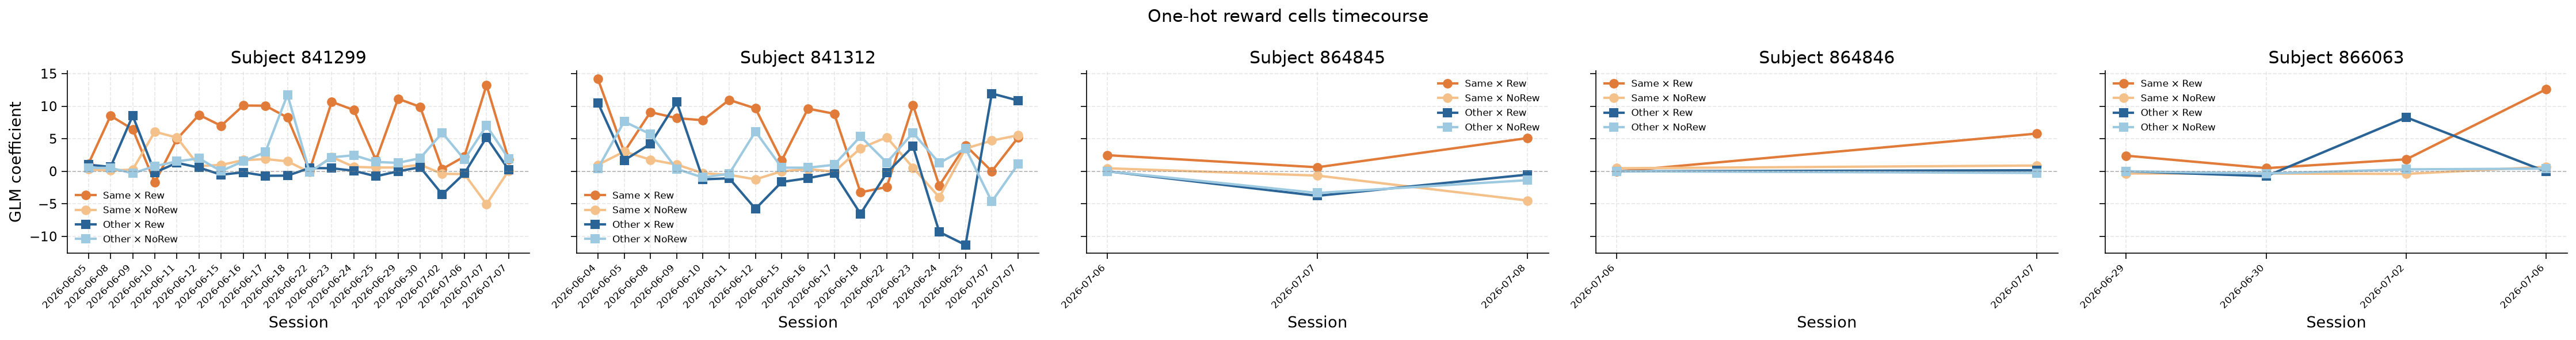

In [13]:

# ── One-hot reward cells timecourse across sessions ───────────────────────────
# 4 distinct colors so solid/dashed ambiguity is avoided entirely
REWARD_CELLS = {
    "H_Same_Rew":    {"label": "Same × Rew",    "color": "#e07b39", "marker": "o"},
    "H_Same_NoRew":  {"label": "Same × NoRew",  "color": "#f5c18a", "marker": "o"},
    "H_Other_Rew":   {"label": "Other × Rew",   "color": "#2a6496", "marker": "s"},
    "H_Other_NoRew": {"label": "Other × NoRew", "color": "#9ecae1", "marker": "s"},
}

with a_lot_of_style():
    fig, axes = plt.subplots(
        1, len(subjects),
        figsize=(6 * len(subjects), 4),
        sharey=True,
        squeeze=False,
    )

    for ax, subject in zip(axes[0], subjects):
        sub      = coefs[coefs["subject_id"] == subject]
        sessions = sorted(sub["session_id"].unique())
        x        = np.arange(len(sessions))
        dates    = [s.split("_")[1] for s in sessions]

        for term, style in REWARD_CELLS.items():
            rows = sub[sub["coef"] == term].set_index("session_id")
            vals = [rows.loc[sid, "value"] if sid in rows.index else np.nan for sid in sessions]
            ax.plot(x, vals,
                    marker=style["marker"], color=style["color"],
                    linewidth=2, markersize=7, label=style["label"])

        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(dates, rotation=45, ha="right", fontsize=8)
        ax.set_xlabel("Session")
        ax.set_title(f"Subject {subject}")
        ax.legend(frameon=False, fontsize=8)

    axes[0][0].set_ylabel("GLM coefficient")
    fig.suptitle("One-hot reward cells timecourse")
    fig.tight_layout()

plt.show()
